# Korea 2026 Crash: Macro Squeeze + Tech Concentration Unwind
**DADS5001 Mini-Project — Visualization Notebook (Macro ➜ Micro)**

ลำดับการเล่าเรื่องในโน้ตบุ๊กนี้ไล่จากภาพใหญ่ไปภาพเล็ก เพื่อให้ผู้อ่านเห็นว่า "แรงกดดันจากภายนอก" ส่งผ่านมาถึง "หุ้นรายตัว" อย่างไร

| บท | ระดับ | คำถามหลัก | Figure |
|---|---|---|---|
| 1 | Macro · ภาพรวม 26 ปี | วิกฤต 2026 รุนแรงแค่ไหนเมื่อเทียบกับอดีต | Fig 1 |
| 2 | Macro · ก่อนวิกฤต (H1) | มีสัญญาณ Stagflation / Rate Trap ก่อตัวหรือไม่ | Fig 2–3 |
| 3 | Macro · ความกลัวระดับโลก (H2) | Risk-off และค่าเงินวอนเป็นตัวจุดชนวนหรือไม่ | Fig 4–6 |
| 4 | Macro · เปรียบเทียบวิกฤต | รูปแบบการร่วงและการฟื้นตัวต่างจากอดีตอย่างไร | Fig 7–8 |
| 5 | สะพานเชื่อม | ปัจจัยใดขยับไปพร้อม KOSPI มากที่สุด | Fig 9 |
| 6 | Micro · โครงสร้างตลาด (H3) | KOSPI พึ่งพาหุ้นชิปมากเกินไปหรือไม่ | Fig 10–12 |
| 7 | Micro · ส่งผ่านจากสหรัฐฯ (H4) | SOX นำหุ้นเกาหลีกี่สัปดาห์ และ Yield/DXY กดดันแค่ไหน | Fig 13–15 |
| 8 | Synthesis | วิกฤต 2026 เป็นวิกฤตโลกหรือวิกฤตเฉพาะเกาหลี และ Early Warning ใช้ได้จริงหรือไม่ | Fig 16–17 |

### แหล่งข้อมูลและข้อจำกัด
โน้ตบุ๊กนี้อ่านข้อมูลจากไฟล์ CSV สองไฟล์ที่ export ไว้แล้ว คือ `macro_monthly.csv` (รายเดือน) และ `weekly_full.csv` (รายสัปดาห์) ซึ่งได้จากโค้ดดึงข้อมูลใน `Mini_Project.ipynb`

| ตัวแปร | แหล่ง | ข้อจำกัด |
|---|---|---|
| `CPI_Korea`, `GDP_Proxy_Monthly` | OECD SDMX | ใช้แทน FRED เดิมที่ข้อมูลขาดช่วง |
| `GDP_Korea` | FRED รายไตรมาส | แปลงเป็นรายเดือนด้วย linear interpolation ซึ่งใช้ค่าไตรมาสถัดไป ห้ามใช้เป็นตัวแปรพยากรณ์ |
| `USDKRW`, `Brent_Oil` | FRED รายวัน | เติมปฏิทินรายวันด้วย ffill ก่อน resample เพราะ index รายเดือน/รายสัปดาห์ไม่ตรงกับวันทำการ |
| `PolicyRate_Korea` | FRED `INTDSRKRM193N` | เป็น Discount Rate ไม่ใช่ BOK Base Rate ระดับต่ำกว่าประมาณ 1.5 จุดเปอร์เซ็นต์ |
| `Samsung`, `SK_Hynix` | yfinance `auto_adjust=False` | ใช้ราคาปิดดิบ เพราะการปรับย้อนหลังเคยทำให้ SK Hynix ได้ค่าติดลบจากประวัติการลดทุน ย้อนได้ถึงปี 2000 |
| `Gold_Price` | yfinance `GC=F` | FRED ยกเลิกซีรีส์ทองคำ และ Stooq ต้องใช้ API key แล้ว ข้อมูลจึงเริ่มแค่ราวปี 2000 |
| `CR5_Concentration` | KRX snapshot + yfinance | ใช้จำนวนหุ้นและมาร์เก็ตแคปรวม ณ วันดึงข้อมูลย้อนหลังทั้งช่วง ดูวิธีปรับแก้ในหัวข้อ 0.1 และ Figure 11 |


## 0. Setup และอ่านข้อมูล
เซลล์ถัดไปจะหาไฟล์ `macro_monthly.csv` และ `weekly_full.csv` ตามลำดับนี้

1. ตัวแปร `df_monthly` / `df_weekly` ถ้ามีอยู่ในหน่วยความจำแล้ว
2. ไฟล์ในโฟลเดอร์ที่ระบุใน `SEARCH_DIRS` ได้แก่ โฟลเดอร์ปัจจุบัน, `data/`, `/content`, `/content/data`, `/content/sample_data`, `/content/drive/MyDrive` และ `/content/drive/MyDrive/DADS5001`
3. ลิงก์ raw ของ GitHub ถ้าตั้งค่า `DATA_URL_BASE` ไว้

**ถ้าต้องการให้เปิดที่เครื่องไหนก็รันได้ทันที** ให้อัปไฟล์ CSV ขึ้น GitHub repo เดียวกับโน้ตบุ๊ก แล้วแก้บรรทัดแรกของเซลล์ถัดไปเป็นลิงก์ raw ของโฟลเดอร์นั้น เช่น

```python
DATA_URL_BASE = "https://raw.githubusercontent.com/USERNAME/REPO/main/data"
```

หลังตั้งค่าแล้วไม่ต้องอัปโหลดไฟล์ใน Colab อีก และไม่ต้อง mount Google Drive


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
})
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

C = {"kospi": "#1f3b73", "samsung": "#1428A0", "hynix": "#E4002B", "sox": "#2a9d8f", "ndx": "#8d6cab",
     "cpi": "#d62828", "cli": "#264653", "oil": "#6c4f3d", "gold": "#c9a227", "vix": "#e76f51",
     "fx": "#0077b6", "rate": "#495057", "grey": "#adb5bd"}

def save(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

DATA_URL_BASE = ""

SEARCH_DIRS = [".", "data", "/content", "/content/data", "/content/sample_data",
               "/content/drive/MyDrive", "/content/drive/MyDrive/DADS5001"]

def read_csv_anywhere(csv_name):
    for d in SEARCH_DIRS:
        p = Path(d) / csv_name
        if p.exists():
            return pd.read_csv(p, parse_dates=["Date"]), str(p)
    if DATA_URL_BASE:
        url = DATA_URL_BASE.rstrip("/") + "/" + csv_name
        return pd.read_csv(url, parse_dates=["Date"]), url
    raise FileNotFoundError(
        f"ไม่พบไฟล์ {csv_name} ในโฟลเดอร์ {SEARCH_DIRS} "
        f"และยังไม่ได้ตั้งค่า DATA_URL_BASE ให้ชี้ไปที่ลิงก์ raw ของ GitHub")

def load_frame(var_name, csv_name):
    if var_name in globals():
        out = globals()[var_name].copy()
        print(f"{var_name}: ใช้ตัวแปรในหน่วยความจำ")
    else:
        out, src = read_csv_anywhere(csv_name)
        out = out.set_index("Date")
        print(f"{var_name}: อ่านจาก {src}")
    out.index = pd.to_datetime(out.index)
    out.index.name = "Date"
    return out.sort_index()

df_m_raw = load_frame("df_monthly", "macro_monthly.csv")
df_w_raw = load_frame("df_weekly", "weekly_full.csv")
print("Monthly:", df_m_raw.shape, "| Weekly:", df_w_raw.shape)

df_monthly: อ่านจาก macro_monthly.csv
df_weekly: อ่านจาก weekly_full.csv
Monthly: (369, 5) | Weekly: (1603, 14)


### 0.1 ทำความสะอาดข้อมูลและสร้างตัวแปรอนุพันธ์
สิ่งที่เซลล์ถัดไปทำ

1. ตัดแถวสุดท้ายที่เป็นสัปดาห์ยังไม่ปิด เพราะ `resample("W-FRI")` ติดป้ายสัปดาห์ปัจจุบันด้วยวันศุกร์ที่ยังมาไม่ถึง
2. เติมราคาด้วย `ffill(limit=2)` สำหรับสัปดาห์ที่ตลาดปิดทั้งสัปดาห์ เช่น ชูซอกปี 2017 ไม่อย่างนั้น rolling window จะขาดช่วง
3. คำนวณผลตอบแทนรายสัปดาห์ ความผันผวน 4 สัปดาห์ และ Drawdown ของ KOSPI
4. สร้าง `CR5_Adj` โดยเปลี่ยนตัวหารของ CR5 จากมาร์เก็ตแคปรวม ณ วัน snapshot วันเดียว ให้เคลื่อนไหวตาม KOSPI และตัดสัปดาห์ที่จำนวนบริษัทในกลุ่มลดลงชั่วคราวจากราคาที่หายไป
5. ยุบข้อมูลรายสัปดาห์เป็นรายเดือนเพื่อรวมกับตาราง Macro แล้วคำนวณ CPI YoY, GDP YoY, ราคาน้ำมันในสกุลวอน, อัตราดอกเบี้ยที่แท้จริง และ Z-score 36 เดือนของ USDKRW


In [2]:
today = pd.Timestamp.today().normalize()
df_w = df_w_raw.loc[df_w_raw.index <= today].copy()
print("ตัดสัปดาห์ที่ยังไม่ปิด:", len(df_w_raw) - len(df_w), "แถว | สัปดาห์สุดท้าย:", df_w.index.max().date())

PRICE_COLS = ["KOSPI", "Samsung", "SK_Hynix", "SOX_Index", "Nasdaq100_Index", "DXY_Index", "Brent_Oil", "Gold_Price", "VIX_Index", "US10Y_Yield"]
df_w[PRICE_COLS] = df_w[PRICE_COLS].ffill(limit=2)
for col in ["KOSPI", "Samsung", "SK_Hynix", "SOX_Index", "Nasdaq100_Index", "DXY_Index", "Brent_Oil", "Gold_Price"]:
    df_w[f"{col}_ret"] = df_w[col].pct_change(fill_method=None) * 100
df_w["US10Y_chg_bp"] = df_w["US10Y_Yield"].diff() * 100
df_w["VIX_chg"] = df_w["VIX_Index"].diff()
df_w["Tech_ret"] = df_w[["Samsung_ret", "SK_Hynix_ret"]].mean(axis=1)
df_w["Tech_Vol_4W"] = df_w["Tech_ret"].rolling(4).std()
df_w["KOSPI_Vol_4W"] = df_w["KOSPI_ret"].rolling(4).std()
df_w["KOSPI_DD"] = (df_w["KOSPI"] - df_w["KOSPI"].cummax()) / df_w["KOSPI"].cummax() * 100

ref_date = df_w_raw["CR5_Concentration"].last_valid_index()
kospi_ref = df_w_raw.loc[ref_date, "KOSPI"]
df_w["CR5_Adj"] = df_w["CR5_Concentration"] * kospi_ref / df_w["KOSPI"] * 100
cnt = df_w["CR5_Company_Count"].fillna(0)
glitch = (cnt == 0) | (cnt < cnt.cummax())
df_w.loc[glitch, ["CR5_Adj", "CR5_Concentration"]] = np.nan

w_to_m = pd.DataFrame({
    "KOSPI": df_w["KOSPI"].resample("MS").last(),
    "PolicyRate_Korea": df_w["PolicyRate_Korea"].resample("MS").last(),
    "Unemployment_Korea": df_w["Unemployment_Korea"].resample("MS").mean(),
    "Brent_Oil": df_w["Brent_Oil"].resample("MS").mean(),
    "VIX_Index": df_w["VIX_Index"].resample("MS").mean(),
    "Gold_Price": df_w["Gold_Price"].resample("MS").last(),
})
df_m = df_m_raw.join(w_to_m, how="outer")
df_m["CPI_YoY"] = df_m["CPI_Korea"].pct_change(12, fill_method=None) * 100
df_m["GDP_YoY"] = df_m["GDP_Korea"].pct_change(12, fill_method=None) * 100
df_m["Brent_KRW"] = df_m["Brent_Oil"] * df_m["USDKRW"]
df_m["Brent_USD_YoY"] = df_m["Brent_Oil"].pct_change(12, fill_method=None) * 100
df_m["Brent_KRW_YoY"] = df_m["Brent_KRW"].pct_change(12, fill_method=None) * 100
df_m["Gold_YoY"] = df_m["Gold_Price"].pct_change(12, fill_method=None) * 100
df_m["KOSPI_ret_1M"] = df_m["KOSPI"].pct_change(fill_method=None) * 100
df_m["KOSPI_fwd_1M"] = df_m["KOSPI_ret_1M"].shift(-1)
df_m["Real_Rate"] = df_m["PolicyRate_Korea"] - df_m["CPI_YoY"]
roll = df_m["USDKRW"].rolling(36, min_periods=24)
df_m["USDKRW_Z36"] = (df_m["USDKRW"] - roll.mean()) / roll.std()

MACRO_START, MICRO_START = "2000-01-01", "2016-01-01"
dm = df_m.loc[MACRO_START:]
dw = df_w.loc[MICRO_START:]
print("Macro rows:", len(dm), "| Micro rows:", len(dw))

ตัดสัปดาห์ที่ยังไม่ปิด: 0 แถว | สัปดาห์สุดท้าย: 2026-09-18
Macro rows: 321 | Micro rows: 560


### 0.2 กำหนดช่วงวิกฤตจากข้อมูล (ไม่ใช้วันที่ตั้งเอง)
หาจุดสูงสุดของ KOSPI ในหน้าต่างก่อนวิกฤต แล้วหาจุดต่ำสุดหลังจากนั้น

In [3]:
CRISIS_WINDOWS = {
    "Dot-com": ("1999-10-01", "2000-03-31", "2001-12-31"),
    "GFC":     ("2007-06-01", "2007-12-31", "2009-03-31"),
    "COVID-19":("2019-12-01", "2020-02-29", "2020-06-30"),
    "2026 Crash": ("2026-05-01", "2026-07-31", str(df_w.index.max().date())),
}
CRISIS_COLORS = {"Dot-com": "#8d99ae", "GFC": "#6d597a", "COVID-19": "#2a9d8f", "2026 Crash": "#d62828"}

rows = []
for name, (p0, p1, t1) in CRISIS_WINDOWS.items():
    k = df_w["KOSPI"]
    peak = k.loc[p0:p1].idxmax()
    trough = k.loc[peak:t1].idxmin()
    after = k.loc[trough:]
    rec = after[after >= k[peak]]
    rows.append({"Crisis": name, "Peak": peak, "Trough": trough,
                 "Peak_KOSPI": k[peak], "Trough_KOSPI": k[trough],
                 "Drawdown_%": (k[trough] / k[peak] - 1) * 100,
                 "Weeks_to_trough": (trough - peak).days // 7,
                 "Weeks_to_recover": (rec.index[0] - trough).days // 7 if len(rec) else np.nan})
crises = pd.DataFrame(rows).set_index("Crisis")
display(crises.round({"Peak_KOSPI": 1, "Trough_KOSPI": 1, "Drawdown_%": 1}))

def shade_crises(ax, start=None, alpha=0.15, label=True):
    for name, r in crises.iterrows():
        if start is not None and r["Trough"] < pd.Timestamp(start):
            continue
        ax.axvspan(r["Peak"], r["Trough"], color=CRISIS_COLORS[name], alpha=alpha, lw=0,
                   label=name if label else None)

,Peak,Trough,Peak_KOSPI,Trough_KOSPI,Drawdown_%,Weeks_to_trough,Weeks_to_recover
Crisis,,,,,,,
Dot-com,1999-12-31,2001-09-21,1028.1,472.3,-54.1,90,199.0
GFC,2007-10-26,2008-10-24,2028.1,938.8,-53.7,52,113.0
COVID-19,2020-01-17,2020-03-20,2250.6,1566.2,-30.4,9,20.0
2026 Crash,2026-06-19,2026-08-07,9052.4,6258.8,-30.9,7,NaN


---
# บทที่ 1 · MACRO: ภาพรวม 26 ปี
**คำถาม:** วิกฤต 2026 อยู่ตรงไหนเมื่อเทียบกับวิกฤตในอดีต และเศรษฐกิจจริงอ่อนแอลงก่อนหรือไม่

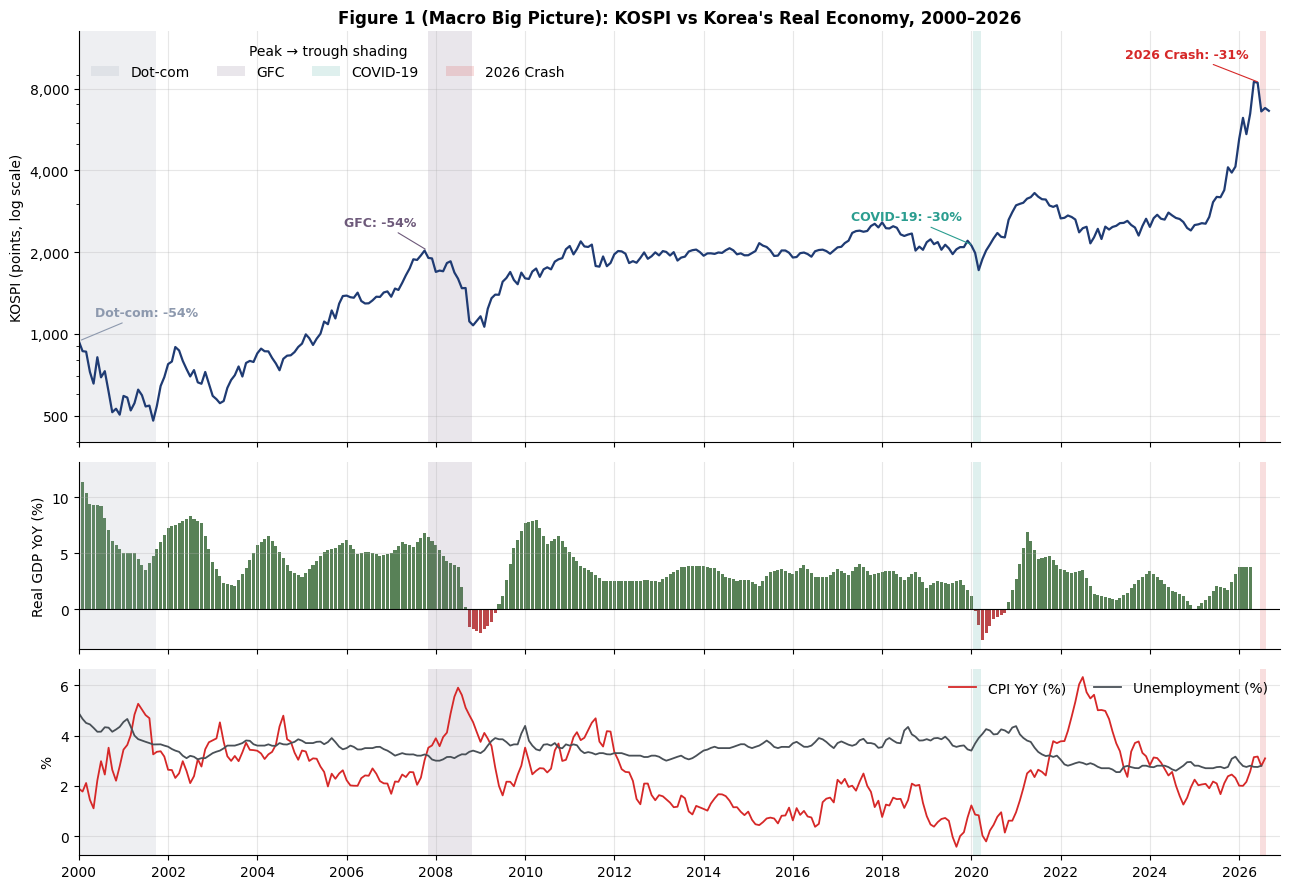

            GDP_YoY  CPI_YoY  Unemployment_Korea
Date                                            
2026-01-01     3.78     2.01                2.95
2026-02-01     3.77     2.00                2.79
2026-03-01     3.76     2.16                2.75
2026-04-01     3.75     2.57                2.80
2026-05-01      NaN     3.14                2.75
2026-06-01      NaN     3.16                2.75
2026-07-01      NaN     2.79                2.80
2026-08-01      NaN     3.09                 NaN


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 1]})
ax = axes[0]
ax.plot(dm.index, dm["KOSPI"], color=C["kospi"], lw=1.6)
ax.set_yscale("log"); ax.set_ylabel("KOSPI (points, log scale)")
ax.set_yticks([500, 1000, 2000, 4000, 8000]); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"{v:,.0f}"))
ax.yaxis.set_minor_formatter(plt.NullFormatter()); ax.set_ylim(400, 13000)
shade_crises(ax)
for name, r in crises.iterrows():
    x_lab = max(r["Peak"], pd.Timestamp(MACRO_START))
    left_side = name == "Dot-com"
    ax.annotate(f"{name}: {r['Drawdown_%']:.0f}%", xy=(x_lab, dm["KOSPI"].asof(x_lab)),
                xytext=(12 if left_side else -8, 18), textcoords="offset points", ha="left" if left_side else "right", fontsize=9,
                color=CRISIS_COLORS[name], fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=CRISIS_COLORS[name], lw=0.8))
ax.legend(loc="upper left", ncol=4, title="Peak → trough shading")
ax.set_title("Figure 1 (Macro Big Picture): KOSPI vs Korea's Real Economy, 2000–2026")

ax = axes[1]
g = dm["GDP_YoY"]
ax.bar(g.index, g, width=25, color=np.where(g >= 0, "#588157", "#bc4749"))
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("Real GDP YoY (%)")
shade_crises(ax, label=False)

ax = axes[2]
ax.plot(dm.index, dm["CPI_YoY"], color=C["cpi"], lw=1.3, label="CPI YoY (%)")
ax.plot(dm.index, dm["Unemployment_Korea"], color=C["rate"], lw=1.3, label="Unemployment (%)")
ax.set_ylabel("%"); ax.legend(loc="upper right", ncol=2)
shade_crises(ax, label=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(pd.Timestamp(MACRO_START), dm.index.max() + pd.DateOffset(months=3))
fig.tight_layout()
save(fig, "fig01_macro_big_picture")

print(dm.loc["2025-06":, ["GDP_YoY", "CPI_YoY", "Unemployment_Korea"]].dropna(how="all").round(2).tail(8))

---
# บทที่ 2 · MACRO ก่อนวิกฤต — H1: Stagflationary & Rate Trap
**Figure 2:** เทียบ OECD CLI (`GDP_Proxy_Monthly`, เส้น 100 = ระดับแนวโน้มปกติ) กับเงินเฟ้อ CPI YoY
พื้นที่แรเงาคือเดือนที่ **CLI < 100 และเงินเฟ้อ > 3%** พร้อมกัน (สัญญาณ Stagflation)

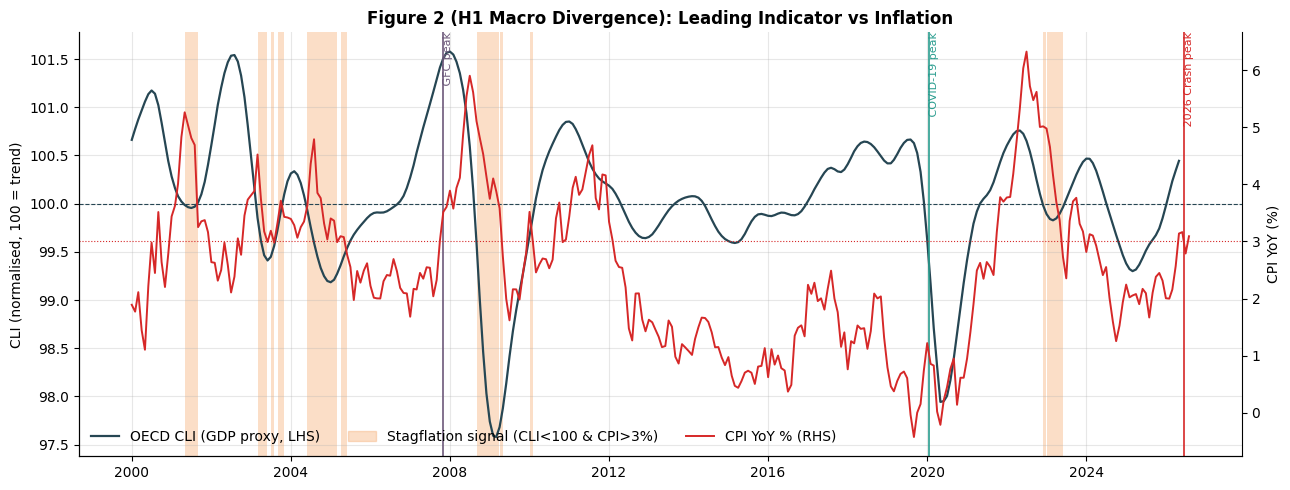

เดือนที่มีสัญญาณ Stagflation ใน 12 เดือนก่อน Peak: {'Dot-com': 0, 'GFC': 0, 'COVID-19': 0, '2026 Crash': 0}


In [5]:
stag_all = (df_m["GDP_Proxy_Monthly"] < 100) & (df_m["CPI_YoY"] > 3)
stag = stag_all.loc[MACRO_START:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(dm.index, dm["GDP_Proxy_Monthly"], color=C["cli"], lw=1.6, label="OECD CLI (GDP proxy, LHS)")
ax.axhline(100, color=C["cli"], ls="--", lw=0.8)
ax.set_ylabel("CLI (normalised, 100 = trend)")
ax2 = ax.twinx()
ax2.plot(dm.index, dm["CPI_YoY"], color=C["cpi"], lw=1.4, label="CPI YoY % (RHS)")
ax2.axhline(3, color=C["cpi"], ls=":", lw=0.8); ax2.set_ylabel("CPI YoY (%)"); ax2.grid(False)
ax2.spines["right"].set_visible(True)
for d in dm.index[stag]:
    ax.axvspan(d, d + pd.offsets.MonthEnd(1), color="#f4a261", alpha=0.35, lw=0)
for name, r in crises.iterrows():
    if r["Peak"] >= pd.Timestamp(MACRO_START):
        ax.axvline(r["Peak"], color=CRISIS_COLORS[name], lw=1.2)
        ax.text(r["Peak"], ax.get_ylim()[1], f" {name} peak", color=CRISIS_COLORS[name], fontsize=8, va="top", rotation=90)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
h1.append(plt.Rectangle((0, 0), 1, 1, color="#f4a261", alpha=0.35)); l1.append("Stagflation signal (CLI<100 & CPI>3%)")
ax.legend(h1 + h2, l1 + l2, loc="lower left", ncol=3)
ax.set_title("Figure 2 (H1 Macro Divergence): Leading Indicator vs Inflation")
fig.tight_layout()
save(fig, "fig02_h1_cli_vs_cpi")

lead = {}
for name, r in crises.iterrows():
    win = stag_all.loc[r["Peak"] - pd.DateOffset(months=12): r["Peak"]]
    lead[name] = int(win.sum()) if len(win) else np.nan
print("เดือนที่มีสัญญาณ Stagflation ใน 12 เดือนก่อน Peak:", lead)

**Figure 3:** ถ้าเงินเฟ้อสูงค้างจากราคาน้ำมัน ธนาคารกลางจะลดดอกเบี้ยได้ยาก (Rate Trap)

⚠️ ซีรีส์ FRED `INTDSRKRM193N` คือ *Discount Rate* ไม่ใช่ BOK Base Rate โดยตรง ทิศทางขยับตามกัน แต่ระดับต่ำกว่าประมาณ 1.5 จุดเปอร์เซ็นต์ (เช่น ช่วงปี 2023 ซีรีส์นี้อยู่ที่ 2.00% ขณะที่ Base Rate อยู่ที่ 3.50%) ค่า Real Rate ในกราฟจึงติดลบเกินจริง ใช้ดู "จังหวะขึ้น/ลง" ได้ แต่ถ้าจะสรุปเรื่อง "ระดับ" ควรเปลี่ยนเป็น Base Rate จาก ECOS ของ BOK
แผงบนดู Policy Rate เทียบเงินเฟ้อ และอัตราดอกเบี้ยที่แท้จริง (Policy − CPI YoY) แผงล่างดูราคาน้ำมันเบรนท์ในสกุลดอลลาร์และวอน

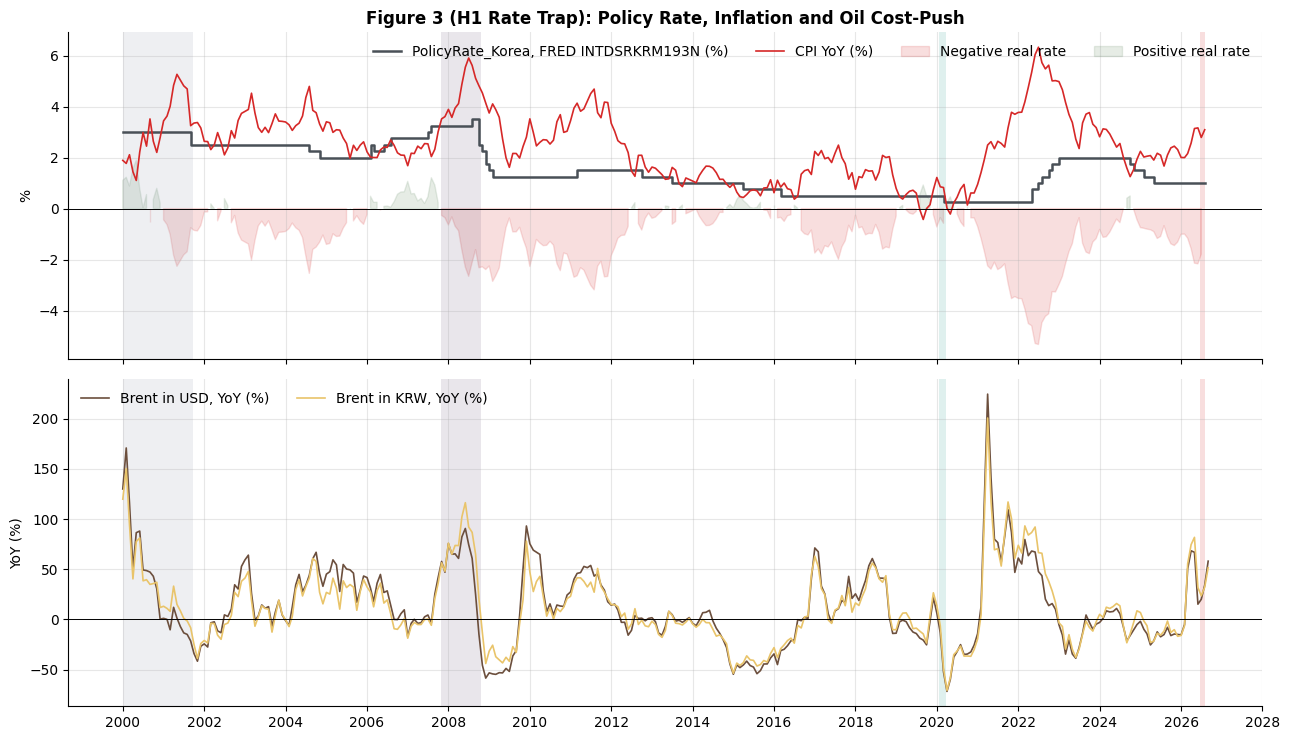

            PolicyRate_Korea  CPI_YoY  Real_Rate  Brent_Oil  Brent_KRW_YoY
Date                                                                      
2025-09-01               1.0     2.10      -1.10      67.75          -1.57
2025-10-01               1.0     2.38      -1.38      64.60         -13.00
2025-11-01               1.0     2.45      -1.45      63.50         -10.18
2025-12-01               1.0     2.31      -1.31      62.90         -16.82
2026-01-01               1.0     2.01      -1.01      66.89         -15.94
2026-02-01               1.0     2.00      -1.00      71.12          -6.27
2026-03-01               1.0     2.16      -1.16     109.72          55.42
2026-04-01               1.0     2.57      -1.57     114.29          74.55
2026-05-01               1.0     3.14      -2.14     107.10          81.79
2026-06-01               1.0     3.16      -2.16      84.14          31.83
2026-07-01               1.0     2.79      -1.79      85.06          23.56
2026-08-01               

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
ax = axes[0]
ax.step(dm.index, dm["PolicyRate_Korea"], where="post", color=C["rate"], lw=1.8, label="PolicyRate_Korea, FRED INTDSRKRM193N (%)")
ax.plot(dm.index, dm["CPI_YoY"], color=C["cpi"], lw=1.2, label="CPI YoY (%)")
rr = dm["Real_Rate"]
ax.fill_between(dm.index, 0, rr, where=rr < 0, color=C["cpi"], alpha=0.15, label="Negative real rate")
ax.fill_between(dm.index, 0, rr, where=rr >= 0, color="#588157", alpha=0.15, label="Positive real rate")
ax.axhline(0, color="black", lw=0.7); ax.set_ylabel("%")
shade_crises(ax, label=False)
ax.legend(loc="upper right", ncol=4)
ax.set_title("Figure 3 (H1 Rate Trap): Policy Rate, Inflation and Oil Cost-Push")

ax = axes[1]
ax.plot(dm.index, dm["Brent_USD_YoY"], color=C["oil"], lw=1.2, label="Brent in USD, YoY (%)")
ax.plot(dm.index, dm["Brent_KRW_YoY"], color="#e9c46a", lw=1.2, label="Brent in KRW, YoY (%)")
ax.axhline(0, color="black", lw=0.7); ax.set_ylabel("YoY (%)")
shade_crises(ax, label=False)
ax.legend(loc="upper left", ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig03_h1_rate_trap_oil")
print(dm.loc["2025-09":"2026-08", ["PolicyRate_Korea", "CPI_YoY", "Real_Rate", "Brent_Oil", "Brent_KRW_YoY"]].round(2))

---
# บทที่ 3 · MACRO ความกลัวระดับโลก — H2: Global Risk-Off & FX Stress
**Figure 4:** VIX (ความตื่นตระหนก) กับราคาทอง (เงินหนีความเสี่ยง) ขยับขึ้นพร้อมกันก่อนวิกฤตหรือไม่

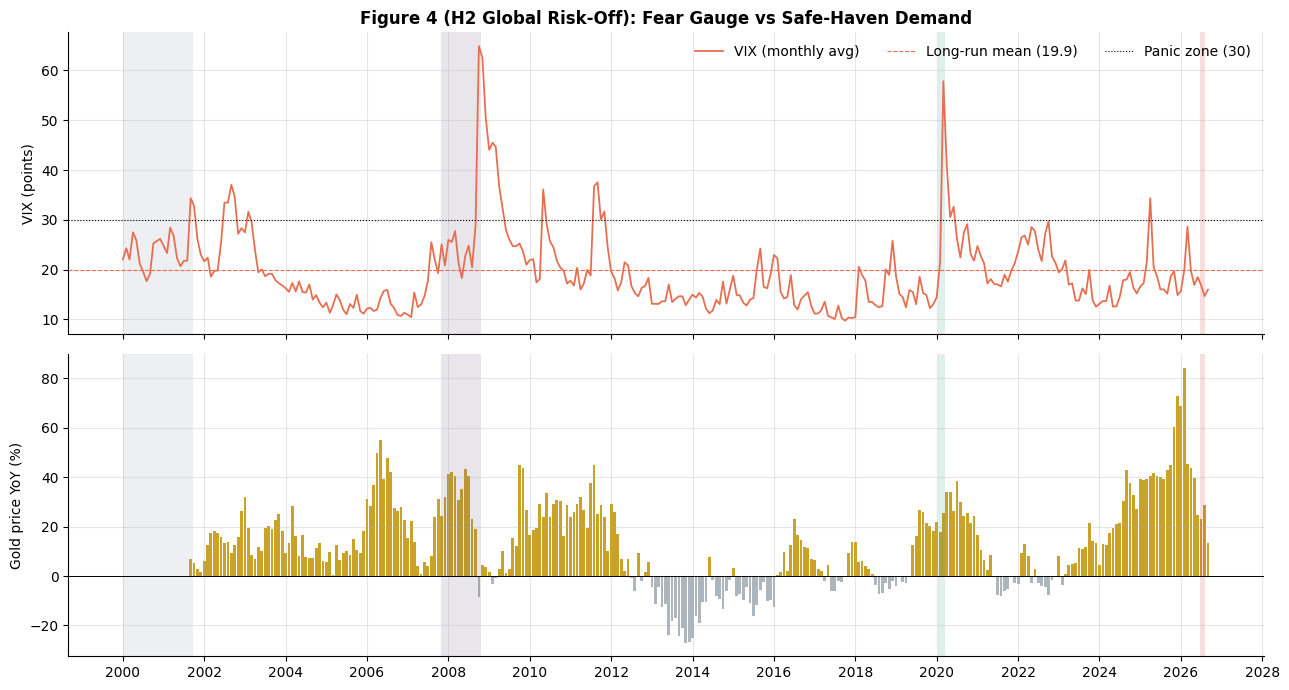

In [7]:
vix_mean = df_w["VIX_Index"].mean()
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax = axes[0]
ax.plot(dm.index, dm["VIX_Index"], color=C["vix"], lw=1.3, label="VIX (monthly avg)")
ax.axhline(vix_mean, color=C["vix"], ls="--", lw=0.8, label=f"Long-run mean ({vix_mean:.1f})")
ax.axhline(30, color="black", ls=":", lw=0.8, label="Panic zone (30)")
ax.set_ylabel("VIX (points)"); shade_crises(ax, label=False); ax.legend(loc="upper right", ncol=3)
ax.set_title("Figure 4 (H2 Global Risk-Off): Fear Gauge vs Safe-Haven Demand")
ax = axes[1]
gy = dm["Gold_YoY"]
ax.bar(gy.index, gy, width=25, color=np.where(gy >= 0, C["gold"], C["grey"]))
ax.axhline(0, color="black", lw=0.7); ax.set_ylabel("Gold price YoY (%)")
shade_crises(ax, label=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig04_h2_vix_gold")

**Figure 5:** ค่าเงินวอนมี "ระดับตัดขาดทุน" หรือไม่
ซ้าย: USDKRW เทียบกรอบ ±2σ ของค่าเฉลี่ยเคลื่อนที่ 36 เดือน · ขวา: ผลตอบแทน KOSPI **เดือนถัดไป** แยกตามระดับ Z-score ของค่าเงิน (ใช้เดือนถัดไปเพื่อไม่ให้เกิด look-ahead)

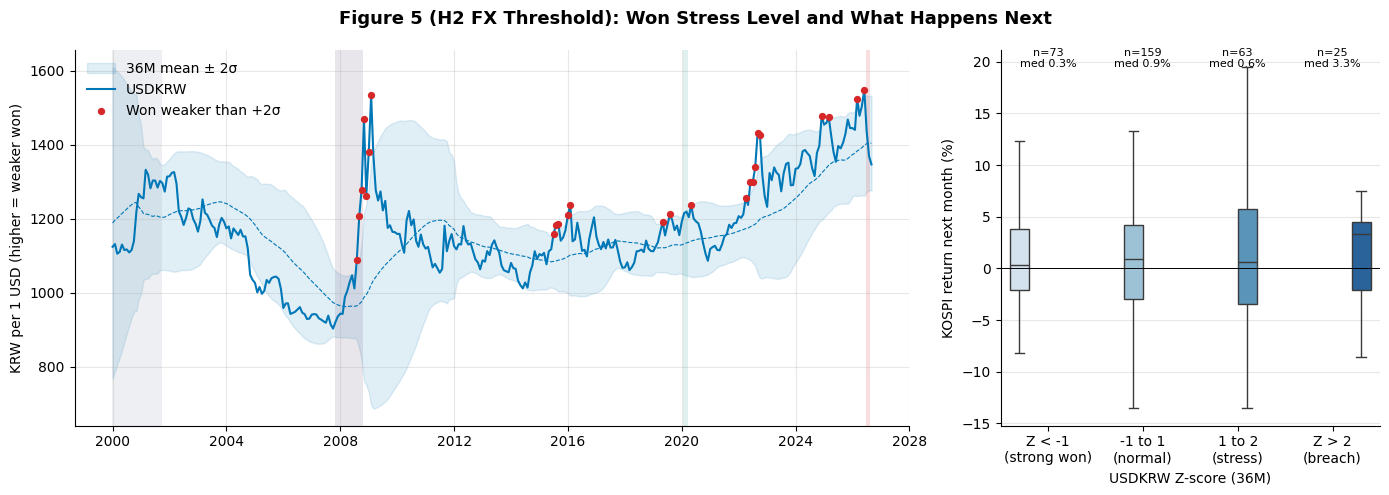

,count,median,mean
FX_bucket,,,
Z < -1\n(strong won),73,0.33,0.79
-1 to 1\n(normal),159,0.87,0.61
1 to 2\n(stress),63,0.61,1.71
Z > 2\n(breach),25,3.31,0.38


USDKRW ระดับที่เคยทะลุ +2σ (เดือน):
Date
2022-04-01    1256.0
2022-06-01    1299.0
2022-07-01    1299.0
2022-08-01    1339.0
2022-09-01    1432.0
2022-10-01    1425.0
2024-12-01    1478.0
2025-03-01    1474.0
2026-03-01    1524.0
2026-06-01    1549.0
Name: USDKRW, dtype: float64


In [8]:
fx = dm[["USDKRW", "USDKRW_Z36", "KOSPI_fwd_1M"]].copy()
r36 = df_m["USDKRW"].rolling(36, min_periods=24)
upper, lower, mid = (r36.mean() + 2 * r36.std()).loc[MACRO_START:], (r36.mean() - 2 * r36.std()).loc[MACRO_START:], r36.mean().loc[MACRO_START:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
ax.fill_between(upper.index, lower, upper, color=C["fx"], alpha=0.12, label="36M mean ± 2σ")
ax.plot(mid.index, mid, color=C["fx"], ls="--", lw=0.8)
ax.plot(fx.index, fx["USDKRW"], color=C["fx"], lw=1.5, label="USDKRW")
br = fx[fx["USDKRW_Z36"] > 2]
ax.scatter(br.index, br["USDKRW"], color="#d62828", s=18, zorder=3, label="Won weaker than +2σ")
shade_crises(ax, label=False)
ax.set_ylabel("KRW per 1 USD (higher = weaker won)"); ax.legend(loc="upper left")
fig.suptitle("Figure 5 (H2 FX Threshold): Won Stress Level and What Happens Next", fontweight="bold", fontsize=13)

bins = [-np.inf, -1, 1, 2, np.inf]
labels = ["Z < -1\n(strong won)", "-1 to 1\n(normal)", "1 to 2\n(stress)", "Z > 2\n(breach)"]
fx["FX_bucket"] = pd.cut(fx["USDKRW_Z36"], bins=bins, labels=labels)
ax = axes[1]
sns.boxplot(data=fx.dropna(), x="FX_bucket", y="KOSPI_fwd_1M", hue="FX_bucket", palette="Blues", legend=False, ax=ax, showfliers=False)
cnt = fx.dropna().groupby("FX_bucket", observed=False)["KOSPI_fwd_1M"].agg(["count", "median", "mean"])
for i, (lab, r) in enumerate(cnt.iterrows()):
    ax.text(i, ax.get_ylim()[1] * 0.92, f"n={int(r['count'])}\nmed {r['median']:.1f}%", ha="center", fontsize=8)
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("USDKRW Z-score (36M)"); ax.set_ylabel("KOSPI return next month (%)")
fig.tight_layout()
save(fig, "fig05_h2_fx_threshold")
display(cnt.round(2))
print("USDKRW ระดับที่เคยทะลุ +2σ (เดือน):"); print(br["USDKRW"].round(0).tail(10))

**Figure 6:** น้ำมันแพงส่งผ่านเป็นเงินเฟ้อเกาหลีด้วยความล่าช้ากี่เดือน และค่าเงินอ่อนทำให้แรงส่งผ่านแรงขึ้นหรือไม่
คำนวณ Cross-correlation ระหว่าง CPI YoY (t) กับ Brent YoY (t − k)

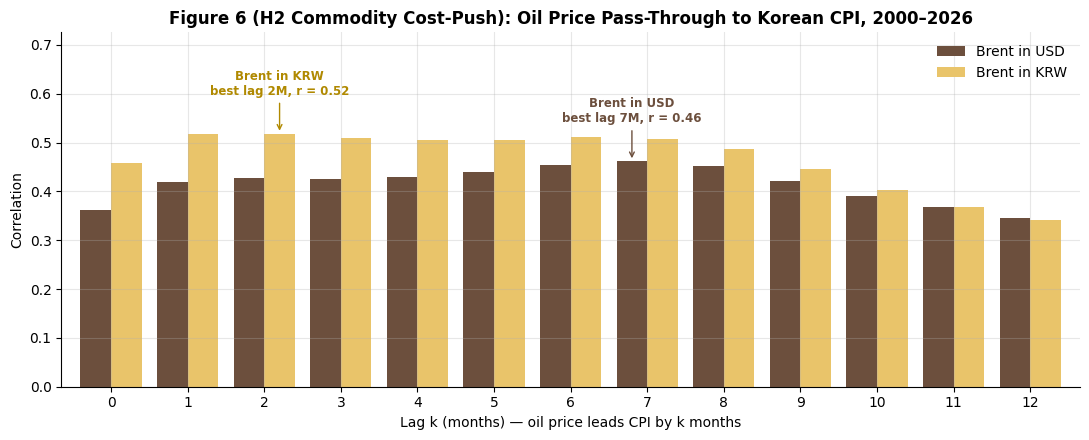

,0,1,2,3,4,5,6,7,8,9,10,11,12
Brent in USD,0.362,0.419,0.427,0.426,0.430,0.440,0.455,0.462,0.452,0.422,0.391,0.367,0.345
Brent in KRW,0.458,0.518,0.518,0.509,0.505,0.506,0.510,0.507,0.487,0.446,0.402,0.369,0.341


In [9]:
lags = range(0, 13)
xc = pd.DataFrame({
    "Brent in USD": [dm["CPI_YoY"].corr(dm["Brent_USD_YoY"].shift(k)) for k in lags],
    "Brent in KRW": [dm["CPI_YoY"].corr(dm["Brent_KRW_YoY"].shift(k)) for k in lags],
}, index=list(lags))

fig, ax = plt.subplots(figsize=(11, 4.5))
xc.plot(kind="bar", ax=ax, color=[C["oil"], "#e9c46a"], width=0.8)
for col, off, colr in [("Brent in USD", -0.2, C["oil"]), ("Brent in KRW", 0.2, "#b08900")]:
    kbest = xc[col].idxmax()
    ax.annotate(f"{col}\nbest lag {kbest}M, r = {xc[col].max():.2f}", xy=(kbest + off, xc[col].max()),
                xytext=(0, 28), textcoords="offset points", ha="center", fontsize=8.5, color=colr, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=colr))
ax.set_xlabel("Lag k (months) — oil price leads CPI by k months"); ax.set_ylabel("Correlation")
ax.set_ylim(0, xc.max().max() * 1.4); ax.tick_params(axis="x", rotation=0)
ax.set_title("Figure 6 (H2 Commodity Cost-Push): Oil Price Pass-Through to Korean CPI, 2000–2026")
fig.tight_layout()
save(fig, "fig06_oil_passthrough_lag")
display(xc.round(3).T)

---
# บทที่ 4 · MACRO เปรียบเทียบวิกฤต (Crash & Recovery Pattern)
**Figure 7:** ปรับทุกวิกฤตให้ Peak = 100 แล้ววางซ้อนกันตามจำนวนสัปดาห์นับจาก Peak

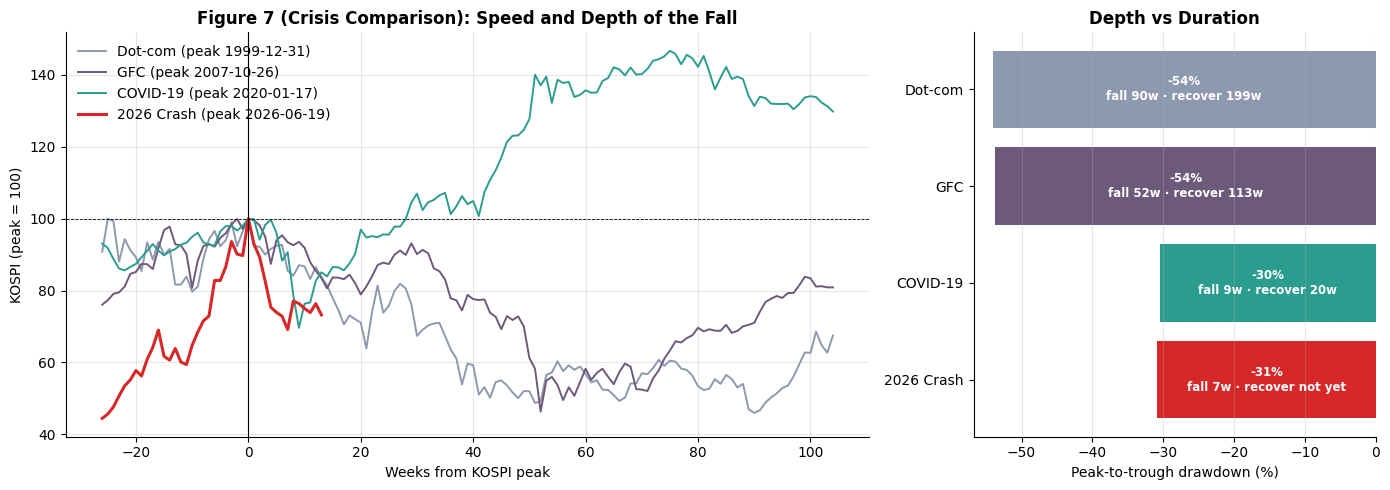

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
for name, r in crises.iterrows():
    s = df_w["KOSPI"].loc[r["Peak"] - pd.Timedelta(weeks=26): r["Peak"] + pd.Timedelta(weeks=104)]
    x = (s.index - r["Peak"]).days / 7
    ax.plot(x, s / r["Peak_KOSPI"] * 100, color=CRISIS_COLORS[name], lw=2.2 if name == "2026 Crash" else 1.4,
            label=f"{name} (peak {r['Peak'].date()})")
ax.axvline(0, color="black", lw=0.8); ax.axhline(100, color="black", lw=0.6, ls="--")
ax.set_xlabel("Weeks from KOSPI peak"); ax.set_ylabel("KOSPI (peak = 100)")
ax.legend(loc="upper left"); ax.set_title("Figure 7 (Crisis Comparison): Speed and Depth of the Fall")

ax = axes[1]
order = crises.index
ax.barh(order, crises["Drawdown_%"], color=[CRISIS_COLORS[n] for n in order])
for i, n in enumerate(order):
    r = crises.loc[n]
    rec = "not yet" if np.isnan(r["Weeks_to_recover"]) else f"{int(r['Weeks_to_recover'])}w"
    ax.text(r["Drawdown_%"] / 2, i, f"{r['Drawdown_%']:.0f}%\nfall {int(r['Weeks_to_trough'])}w · recover {rec}",
            va="center", ha="center", fontsize=8.5, color="white", fontweight="bold")
ax.set_xlabel("Peak-to-trough drawdown (%)"); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_title("Depth vs Duration")
fig.tight_layout()
save(fig, "fig07_crisis_comparison")

**Figure 8 (Post-Crash Recovery):** ตลาดเริ่มฟื้นหลัง "ดอกเบี้ยเริ่มลด" หรือหลัง "VIX ลงต่ำกว่าค่าเฉลี่ยระยะยาว"
เส้นประสีเทา = การลดดอกเบี้ยครั้งแรกหลัง Peak · เส้นประสีส้ม = สัปดาห์แรกหลัง Trough ที่ VIX < ค่าเฉลี่ยระยะยาว

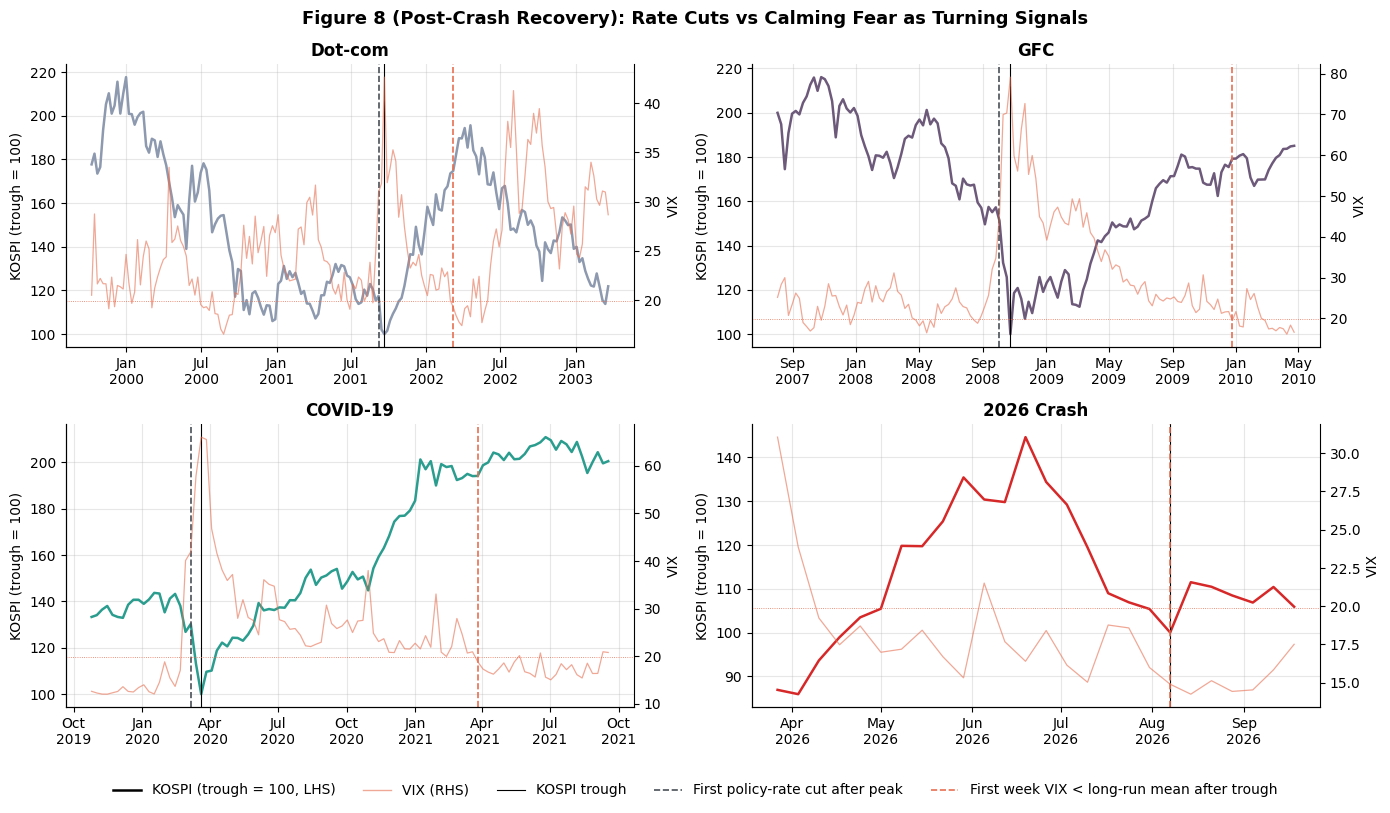

,First rate cut,Cut vs trough (weeks),VIX < mean (date),VIX-calm vs trough (weeks),KOSPI 26w after VIX-calm (%)
Crisis,,,,,
Dot-com,2001-09-07,-2.0,2002-03-08,24,-14.1
GFC,2008-10-03,-3.0,2009-12-25,61,2.8
COVID-19,2020-03-06,-2.0,2021-03-26,53,2.8
2026 Crash,None,NaN,2026-08-07,0,NaN


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
recovery_rows = []
for ax, (name, r) in zip(axes.flat, crises.iterrows()):
    win = df_w.loc[r["Peak"] - pd.Timedelta(weeks=12): r["Trough"] + pd.Timedelta(weeks=78)]
    ax.plot(win.index, win["KOSPI"] / r["Trough_KOSPI"] * 100, color=CRISIS_COLORS[name], lw=1.8, label="KOSPI (trough = 100)")
    ax.axvline(r["Trough"], color="black", lw=0.8)
    ax.set_ylabel("KOSPI (trough = 100)")
    axv = ax.twinx(); axv.grid(False); axv.spines["right"].set_visible(True)
    axv.plot(win.index, win["VIX_Index"], color=C["vix"], lw=0.9, alpha=0.6, label="VIX (RHS)")
    axv.axhline(vix_mean, color=C["vix"], lw=0.6, ls=":")
    axv.set_ylabel("VIX")
    cuts = win.loc[r["Peak"]:, "PolicyRate_Korea"].diff()
    first_cut = cuts[cuts < 0].index.min()
    calm = win.loc[r["Trough"]:, "VIX_Index"]
    first_calm = calm[calm < vix_mean].index.min()
    if pd.notna(first_cut):
        ax.axvline(first_cut, color=C["rate"], ls="--", lw=1.2)
    if pd.notna(first_calm):
        ax.axvline(first_calm, color=C["vix"], ls="--", lw=1.2)
    fwd = lambda d: (df_w["KOSPI"].asof(d + pd.Timedelta(weeks=26)) / df_w["KOSPI"].asof(d) - 1) * 100 \
        if pd.notna(d) and d + pd.Timedelta(weeks=26) <= df_w.index.max() else np.nan
    recovery_rows.append({"Crisis": name,
                          "First rate cut": first_cut.date() if pd.notna(first_cut) else None,
                          "Cut vs trough (weeks)": (first_cut - r["Trough"]).days // 7 if pd.notna(first_cut) else np.nan,
                          "VIX < mean (date)": first_calm.date() if pd.notna(first_calm) else None,
                          "VIX-calm vs trough (weeks)": (first_calm - r["Trough"]).days // 7 if pd.notna(first_calm) else np.nan,
                          "KOSPI 26w after VIX-calm (%)": fwd(first_calm)})
    ax.set_title(name); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.suptitle("Figure 8 (Post-Crash Recovery): Rate Cuts vs Calming Fear as Turning Signals", fontweight="bold", fontsize=13)
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([], [], color="black", lw=1.8, label="KOSPI (trough = 100, LHS)"),
                    Line2D([], [], color=C["vix"], lw=1, alpha=0.6, label="VIX (RHS)"),
                    Line2D([], [], color="black", lw=0.8, label="KOSPI trough"),
                    Line2D([], [], color=C["rate"], ls="--", lw=1.2, label="First policy-rate cut after peak"),
                    Line2D([], [], color=C["vix"], ls="--", lw=1.2, label="First week VIX < long-run mean after trough")],
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.04, 1, 1))
save(fig, "fig08_recovery_signals")
recovery = pd.DataFrame(recovery_rows).set_index("Crisis")
display(recovery.round(1))

---
# บทที่ 5 · สะพานเชื่อม Macro ➜ Micro
**Figure 9:** ในยุค 2016–2026 ปัจจัยใดขยับไปพร้อม KOSPI รายสัปดาห์มากที่สุด (ใช้ % เปลี่ยนแปลงรายสัปดาห์ ไม่ใช่ระดับราคา เพื่อเลี่ยง spurious correlation จากแนวโน้มร่วม)

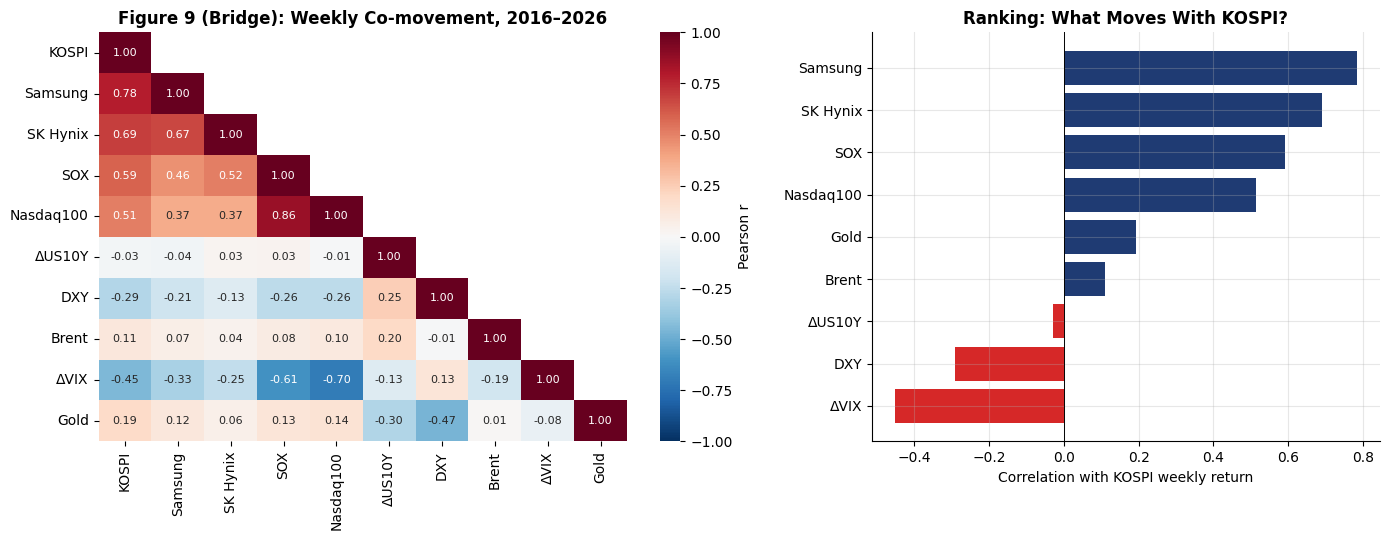

In [12]:
corr_cols = {"KOSPI_ret": "KOSPI", "Samsung_ret": "Samsung", "SK_Hynix_ret": "SK Hynix",
             "SOX_Index_ret": "SOX", "Nasdaq100_Index_ret": "Nasdaq100", "US10Y_chg_bp": "ΔUS10Y",
             "DXY_Index_ret": "DXY", "Brent_Oil_ret": "Brent", "VIX_chg": "ΔVIX", "Gold_Price_ret": "Gold"}
cm = dw[list(corr_cols)].rename(columns=corr_cols).corr()
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=axes[0], cbar_kws={"label": "Pearson r"}, annot_kws={"size": 8})
axes[0].grid(False)
axes[0].set_title("Figure 9 (Bridge): Weekly Co-movement, 2016–2026")
k_corr = cm["KOSPI"].drop("KOSPI").sort_values()
axes[1].barh(k_corr.index, k_corr, color=np.where(k_corr > 0, C["kospi"], C["cpi"]))
axes[1].axvline(0, color="black", lw=0.7)
axes[1].set_xlabel("Correlation with KOSPI weekly return"); axes[1].set_title("Ranking: What Moves With KOSPI?")
fig.tight_layout()
save(fig, "fig09_bridge_correlation")

---
# บทที่ 6 · MICRO โครงสร้างตลาด — H3: Concentration Fragility
**Figure 10:** ตั้งฐานปี 2016 = 100 เพื่อดูว่าใครเป็นคนลาก KOSPI ขึ้น

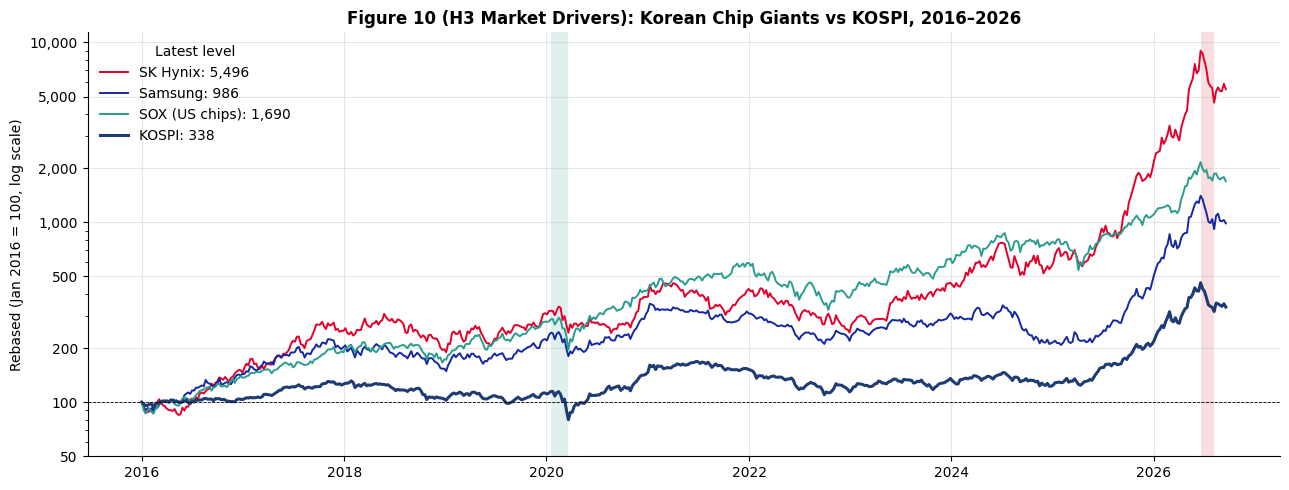

In [13]:
base = dw[["KOSPI", "Samsung", "SK_Hynix", "SOX_Index"]].dropna().iloc[0]
reb = dw[["KOSPI", "Samsung", "SK_Hynix", "SOX_Index"]] / base * 100
fig, ax = plt.subplots(figsize=(13, 5))
for col, lab in [("SK_Hynix", "SK Hynix"), ("Samsung", "Samsung"), ("SOX_Index", "SOX (US chips)"), ("KOSPI", "KOSPI")]:
    key = {"SK_Hynix": "hynix", "Samsung": "samsung", "SOX_Index": "sox", "KOSPI": "kospi"}[col]
    ax.plot(reb.index, reb[col], color=C[key], lw=2.2 if col == "KOSPI" else 1.4, label=f"{lab}: {reb[col].dropna().iloc[-1]:,.0f}")
ax.set_yscale("log"); ax.axhline(100, color="black", lw=0.6, ls="--")
ax.set_yticks([50, 100, 200, 500, 1000, 2000, 5000, 10000]); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"{v:,.0f}"))
ax.yaxis.set_minor_formatter(plt.NullFormatter())
shade_crises(ax, start=MICRO_START, label=False)
ax.set_ylabel("Rebased (Jan 2016 = 100, log scale)"); ax.legend(loc="upper left", title="Latest level")
ax.set_title("Figure 10 (H3 Market Drivers): Korean Chip Giants vs KOSPI, 2016–2026")
fig.tight_layout()
save(fig, "fig10_h3_rebased_drivers")

**Figure 11:** สัดส่วนมาร์เก็ตแคป Top-5 (CR5) เทียบกับ Drawdown ของ KOSPI

⚠️ `CR5_Concentration` ที่ดึงมาใช้ตัวหารเป็นมาร์เก็ตแคปรวม ณ วันดึงข้อมูลค่าเดียว ค่าในอดีตจึงสูงหรือต่ำตามระดับราคาหุ้น
จึงแสดง `CR5_Adj` ที่ปรับตัวหารให้เคลื่อนตาม KOSPI (สมมติว่ามาร์เก็ตแคปรวมเคลื่อนไหวตามดัชนี) เป็นเส้นหลัก และแสดงค่าดิบเป็นเส้นประเพื่อเปรียบเทียบ
เส้นแนวตั้งคือจุดที่จำนวนบริษัทใน CR5 เปลี่ยน (หุ้น IPO เข้ามา) ซึ่งทำให้กราฟกระโดดเชิงเทคนิค

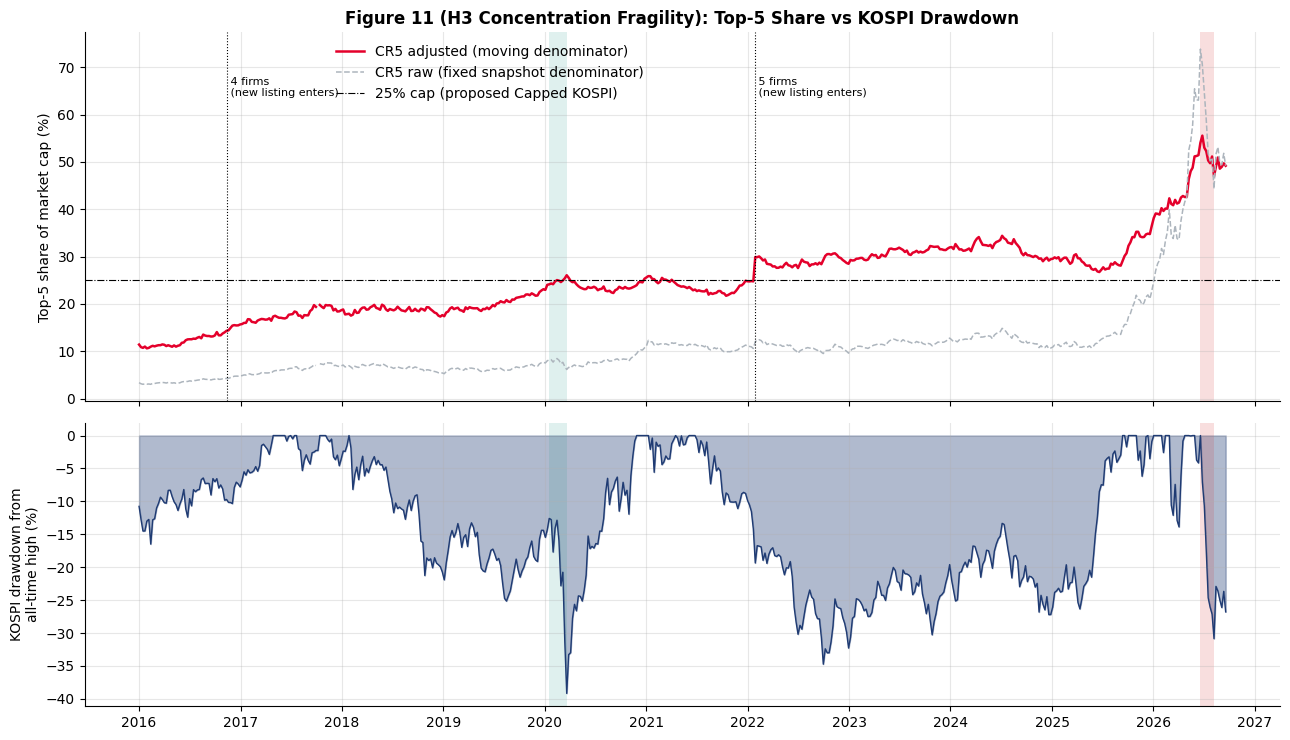

Date                    2016-01-01  2017-01-01  2018-01-01  2019-01-01  \
CR5_Adj yearly avg (%)        12.5        17.7        18.7        20.1   

Date                    2020-01-01  2021-01-01  2022-01-01  2023-01-01  \
CR5_Adj yearly avg (%)        23.8        23.6        28.7        30.8   

Date                    2024-01-01  2025-01-01  2026-01-01  
CR5_Adj yearly avg (%)        31.8        30.1        45.8  


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
ax = axes[0]
ax.plot(dw.index, dw["CR5_Adj"], color=C["hynix"], lw=1.8, label="CR5 adjusted (moving denominator)")
ax.plot(dw.index, dw["CR5_Concentration"] * 100, color=C["grey"], lw=1.1, ls="--", label="CR5 raw (fixed snapshot denominator)")
cm_cnt = df_w["CR5_Company_Count"].fillna(0).cummax()
entries = cm_cnt[cm_cnt.diff() > 0].loc[MICRO_START:]
for d in entries.index:
    ax.axvline(d, color="black", lw=0.8, ls=":")
    ax.text(d, 68, f" {int(entries[d])} firms\n (new listing enters)", fontsize=8, va="top")
ax.axhline(25, color="black", lw=0.8, ls="-.", label="25% cap (proposed Capped KOSPI)")
ax.set_ylabel("Top-5 share of market cap (%)"); ax.legend(loc="upper left", bbox_to_anchor=(0.2, 1.0))
shade_crises(ax, start=MICRO_START, label=False)
ax.set_title("Figure 11 (H3 Concentration Fragility): Top-5 Share vs KOSPI Drawdown")
ax = axes[1]
ax.fill_between(dw.index, dw["KOSPI_DD"], 0, color=C["kospi"], alpha=0.35)
ax.plot(dw.index, dw["KOSPI_DD"], color=C["kospi"], lw=1)
ax.set_ylabel("KOSPI drawdown from\nall-time high (%)")
shade_crises(ax, start=MICRO_START, label=False)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig11_h3_concentration_drawdown")
print(dw["CR5_Adj"].resample("YS").mean().round(1).rename("CR5_Adj yearly avg (%)").to_frame().T)

**Figure 12 (Loss Contribution):** มาร์เก็ตแคปที่หายไประหว่าง Peak ➜ Trough มาจาก Top-5 กี่เปอร์เซ็นต์

วิธีคำนวณ: มาร์เก็ตแคป Top-5 ÷ มาร์เก็ตแคปรวม ณ snapshot = `CR5` และมาร์เก็ตแคปรวม ณ t ≈ snapshot × KOSPI(t)/KOSPI(snapshot)
ตัวหาร snapshot จึงตัดกันหายไป ถ้ามีตัวแปร `shares_outstanding` และ `total_market_cap_snapshot` จากเซลล์ดึงข้อมูล จะแยก Samsung และ SK Hynix ออกมาให้ด้วย

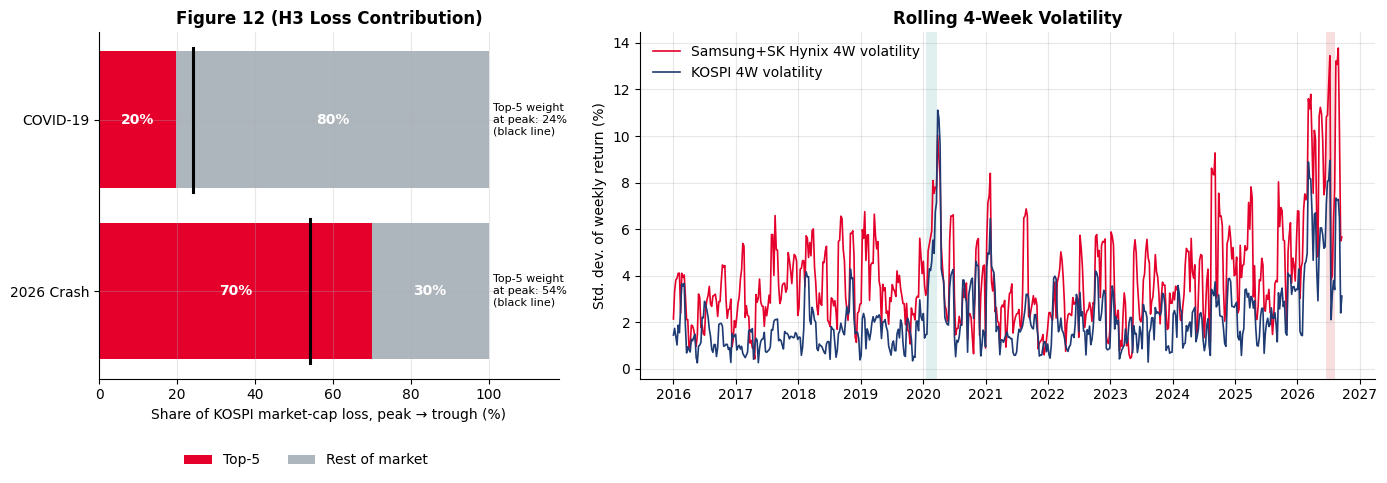

,Top-5,Rest of market
COVID-19,19.8,80.2
2026 Crash,69.9,30.1


In [15]:
def loss_contribution(peak, trough):
    k_p, k_t = df_w.loc[peak, "KOSPI"], df_w.loc[trough, "KOSPI"]
    total_drop = (k_p - k_t) / kospi_ref
    top5_drop = df_w.loc[peak, "CR5_Concentration"] - df_w.loc[trough, "CR5_Concentration"]
    out = {"Top-5": top5_drop / total_drop * 100}
    if "shares_outstanding" in globals() and "total_market_cap_snapshot" in globals():
        for nm in ["Samsung", "SK_Hynix"]:
            d = (df_w.loc[peak, nm] - df_w.loc[trough, nm]) * shares_outstanding[nm] / total_market_cap_snapshot
            out[nm] = d / total_drop * 100
        out["Other Top-5"] = out["Top-5"] - out["Samsung"] - out["SK_Hynix"]
        del out["Top-5"]
    out["Rest of market"] = 100 - sum(out.values())
    return out

contrib = pd.DataFrame({n: loss_contribution(crises.loc[n, "Peak"], crises.loc[n, "Trough"])
                        for n in ["COVID-19", "2026 Crash"]}).T
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.6]})
ax = axes[0]
palette = {"Top-5": C["hynix"], "Samsung": C["samsung"], "SK_Hynix": C["hynix"], "Other Top-5": "#f4a261", "Rest of market": C["grey"]}
left = np.zeros(len(contrib))
for col in contrib.columns:
    ax.barh(contrib.index, contrib[col], left=left, color=palette[col], label=col)
    for i, v in enumerate(contrib[col]):
        if v > 6:
            ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    left += contrib[col].values
for i, n in enumerate(contrib.index):
    wpk = df_w.loc[crises.loc[n, "Peak"], "CR5_Adj"]
    ax.plot([wpk, wpk], [i - 0.42, i + 0.42], color="black", lw=2.2)
    ax.text(101, i, f"Top-5 weight\nat peak: {wpk:.0f}%\n(black line)", va="center", fontsize=8)
ax.set_xlim(0, 118); ax.set_xlabel("Share of KOSPI market-cap loss, peak → trough (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.45, -0.18), ncol=3); ax.invert_yaxis()
ax.set_title("Figure 12 (H3 Loss Contribution)")

ax = axes[1]
ax.plot(dw.index, dw["Tech_Vol_4W"], color=C["hynix"], lw=1.2, label="Samsung+SK Hynix 4W volatility")
ax.plot(dw.index, dw["KOSPI_Vol_4W"], color=C["kospi"], lw=1.2, label="KOSPI 4W volatility")
shade_crises(ax, start=MICRO_START, label=False)
ax.set_ylabel("Std. dev. of weekly return (%)"); ax.legend(loc="upper left")
ax.set_title("Rolling 4-Week Volatility")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig12_h3_loss_contribution_vol")
display(contrib.round(1))

---
# บทที่ 7 · MICRO กลไกส่งผ่านจากสหรัฐฯ — H4: Spillover vs Valuation Compression
**Figure 13:** Rolling Correlation 12 สัปดาห์ ระหว่างหุ้นชิปเกาหลีกับดัชนีเทคสหรัฐฯ

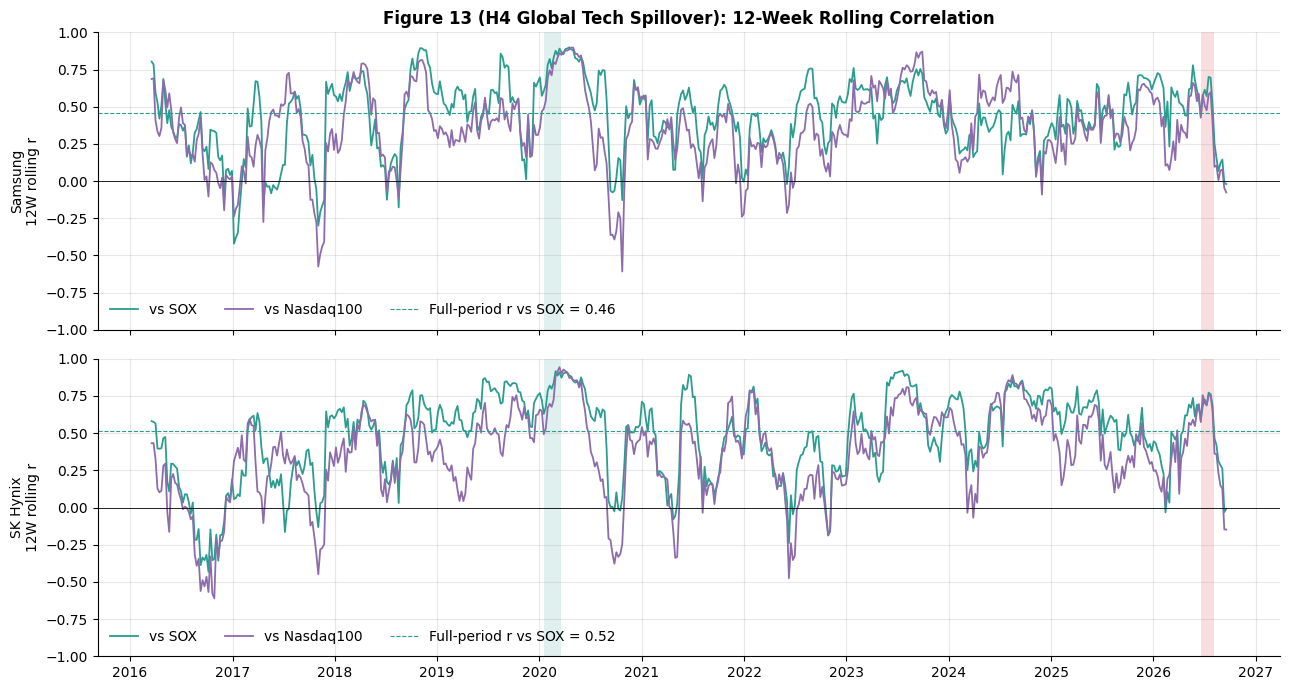

ค่าเฉลี่ย 12W rolling r: 12 สัปดาห์ก่อน Peak 2026 เทียบกับค่าเฉลี่ยทั้งช่วง 2016–2025


,12W before 2026 peak,Avg 2016–2025
Samsung vs SOX,0.57,0.43
Samsung vs Nasdaq100,0.46,0.36
SK Hynix vs SOX,0.59,0.48
SK Hynix vs Nasdaq100,0.49,0.36


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
roll_tbl = {}
for ax, (stock, lab) in zip(axes, [("Samsung_ret", "Samsung"), ("SK_Hynix_ret", "SK Hynix")]):
    for idx, key, nm in [("SOX_Index_ret", "sox", "SOX"), ("Nasdaq100_Index_ret", "ndx", "Nasdaq100")]:
        rc = dw[stock].rolling(12).corr(dw[idx])
        roll_tbl[f"{lab} vs {nm}"] = rc
        ax.plot(rc.index, rc, color=C[key], lw=1.3, label=f"vs {nm}")
    full = dw[stock].corr(dw["SOX_Index_ret"])
    ax.axhline(full, color=C["sox"], ls="--", lw=0.8, label=f"Full-period r vs SOX = {full:.2f}")
    ax.axhline(0, color="black", lw=0.6)
    shade_crises(ax, start=MICRO_START, label=False)
    ax.set_ylim(-1, 1); ax.set_ylabel(f"{lab}\n12W rolling r"); ax.legend(loc="lower left", ncol=3)
axes[0].set_title("Figure 13 (H4 Global Tech Spillover): 12-Week Rolling Correlation")
axes[1].xaxis.set_major_locator(mdates.YearLocator()); axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig13_h4_rolling_correlation")

peak26 = crises.loc["2026 Crash", "Peak"]
roll_df = pd.DataFrame(roll_tbl)
print("ค่าเฉลี่ย 12W rolling r: 12 สัปดาห์ก่อน Peak 2026 เทียบกับค่าเฉลี่ยทั้งช่วง 2016–2025")
display(pd.DataFrame({"12W before 2026 peak": roll_df.loc[peak26 - pd.Timedelta(weeks=12): peak26].mean(),
                      "Avg 2016–2025": roll_df.loc[:"2025-12-31"].mean()}).round(2))

**Figure 14 (Lead–Lag):** SOX ของสัปดาห์ก่อนหน้า (t − k) สัมพันธ์กับหุ้นเกาหลีสัปดาห์นี้ (t) แค่ไหน

⚠️ ข้อควรระวังเรื่องเวลา: ตลาดเกาหลีปิดวันศุกร์ก่อนตลาดสหรัฐฯ เปิด ความเคลื่อนไหวของ SOX ในวันศุกร์จึงไปสะท้อนในหุ้นเกาหลีสัปดาห์ถัดไป ค่า lag 1 ส่วนหนึ่งจึงมาจากเขตเวลา ไม่ใช่การนำจริงทั้งหมด

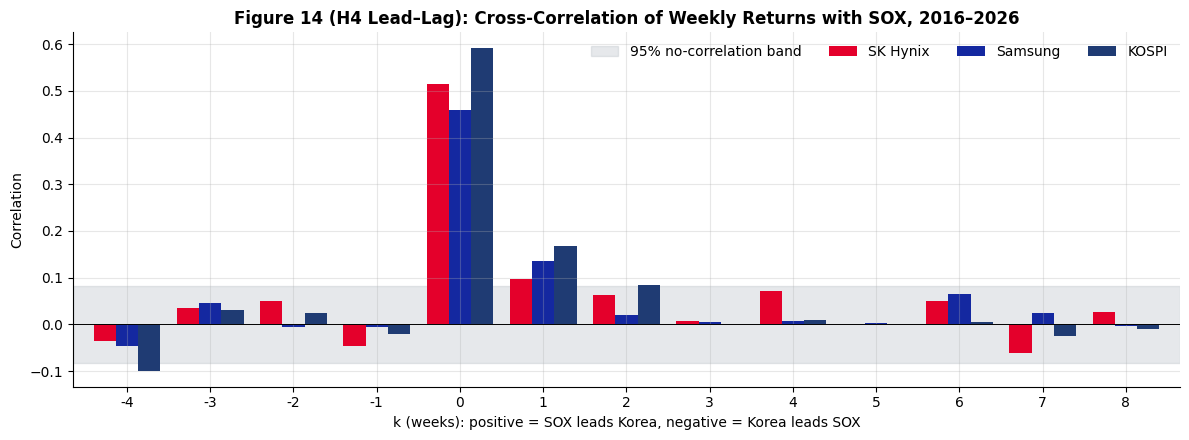

,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8
SK Hynix,-0.036,0.036,0.050,-0.047,0.515,0.098,0.062,0.008,0.072,0.000,0.050,-0.060,0.027
Samsung,-0.045,0.045,-0.006,-0.005,0.460,0.136,0.020,0.004,0.007,0.003,0.065,0.024,-0.004
KOSPI,-0.099,0.032,0.025,-0.020,0.591,0.169,0.085,0.002,0.010,0.000,0.006,-0.024,-0.010


In [17]:
lag_range = range(-4, 9)
cc = pd.DataFrame({lab: [dw[col].corr(dw["SOX_Index_ret"].shift(k)) for k in lag_range]
                   for col, lab in [("SK_Hynix_ret", "SK Hynix"), ("Samsung_ret", "Samsung"), ("KOSPI_ret", "KOSPI")]},
                  index=list(lag_range))
n_obs = dw["KOSPI_ret"].notna().sum()
sig = 1.96 / np.sqrt(n_obs)
fig, ax = plt.subplots(figsize=(12, 4.5))
cc.plot(kind="bar", ax=ax, color=[C["hynix"], C["samsung"], C["kospi"]], width=0.8)
ax.axhspan(-sig, sig, color=C["grey"], alpha=0.3, label="95% no-correlation band", zorder=0)
ax.axhline(0, color="black", lw=0.7); ax.tick_params(axis="x", rotation=0)
ax.set_xlabel("k (weeks): positive = SOX leads Korea, negative = Korea leads SOX"); ax.set_ylabel("Correlation")
ax.legend(ncol=4, loc="upper right")
ax.set_title("Figure 14 (H4 Lead–Lag): Cross-Correlation of Weekly Returns with SOX, 2016–2026")
fig.tight_layout()
save(fig, "fig14_h4_cross_correlation")
display(cc.round(3).T)

**Figure 15 (Valuation Pressure):** Yield สหรัฐฯ ที่สูงขึ้นและดอลลาร์ที่แข็งค่า กดหุ้นชิปเกาหลีหรือไม่
บน: ความสัมพันธ์รายสัปดาห์ (จุดสีแดง = สัปดาห์ในปี 2026) · ล่าง: Rolling correlation 26 สัปดาห์

⚠️ ข้อจำกัด: ชุดข้อมูลไม่มีกำไรต่อหุ้น (EPS) จึง **ยืนยัน P/E Multiple Compression โดยตรงไม่ได้** สิ่งที่ทดสอบได้คือความไวของราคาต่อ Yield และ DXY เท่านั้น ถ้าต้องการแยก Valuation กับ Earnings ต้องเพิ่มข้อมูล Forward EPS

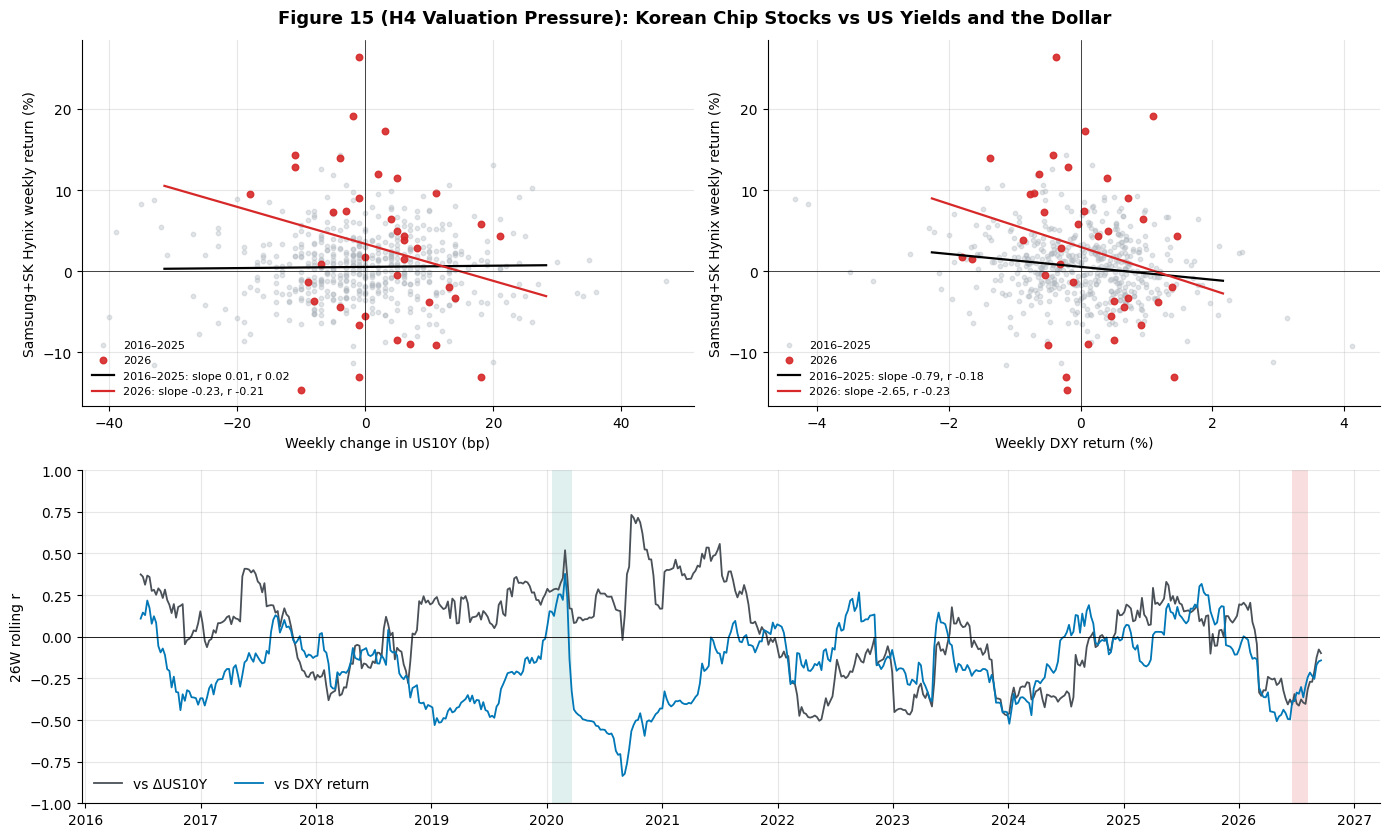

slope      r      n
Weekly change in US10Y (bp) 2016–2025  0.007  0.021  522.0
                            2026      -0.228 -0.212   38.0
Weekly DXY return (%)       2016–2025 -0.792 -0.185  522.0
                            2026      -2.651 -0.227   38.0

In [18]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(14, 8.5))
gs = GridSpec(2, 2, height_ratios=[1.1, 1], figure=fig)
beta_rows = {}
for j, (xcol, xlab) in enumerate([("US10Y_chg_bp", "Weekly change in US10Y (bp)"), ("DXY_Index_ret", "Weekly DXY return (%)")]):
    ax = fig.add_subplot(gs[0, j])
    d = dw[[xcol, "Tech_ret"]].dropna()
    pre, y26 = d.loc[:"2025-12-31"], d.loc["2026-01-01":]
    ax.scatter(pre[xcol], pre["Tech_ret"], s=10, alpha=0.35, color=C["grey"], label="2016–2025")
    ax.scatter(y26[xcol], y26["Tech_ret"], s=22, alpha=0.9, color="#d62828", label="2026")
    for sub, colr, nm in [(pre, "black", "2016–2025"), (y26, "#d62828", "2026")]:
        b, a = np.polyfit(sub[xcol], sub["Tech_ret"], 1)
        xs = np.linspace(d[xcol].quantile(0.01), d[xcol].quantile(0.99), 50)
        ax.plot(xs, a + b * xs, color=colr, lw=1.6, label=f"{nm}: slope {b:.2f}, r {sub[xcol].corr(sub['Tech_ret']):.2f}")
        beta_rows[(xlab, nm)] = {"slope": b, "r": sub[xcol].corr(sub["Tech_ret"]), "n": len(sub)}
    ax.axhline(0, color="black", lw=0.5); ax.axvline(0, color="black", lw=0.5)
    ax.set_xlabel(xlab); ax.set_ylabel("Samsung+SK Hynix weekly return (%)"); ax.legend(loc="lower left", fontsize=8)
ax_r = fig.add_subplot(gs[1, :])
for xcol, colr, nm in [("US10Y_chg_bp", C["rate"], "vs ΔUS10Y"), ("DXY_Index_ret", C["fx"], "vs DXY return")]:
    rc = dw["Tech_ret"].rolling(26).corr(dw[xcol])
    ax_r.plot(rc.index, rc, color=colr, lw=1.3, label=nm)
ax_r.axhline(0, color="black", lw=0.6); shade_crises(ax_r, start=MICRO_START, label=False)
ax_r.set_ylabel("26W rolling r"); ax_r.set_ylim(-1, 1); ax_r.legend(loc="lower left", ncol=2)
ax_r.xaxis.set_major_locator(mdates.YearLocator()); ax_r.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Figure 15 (H4 Valuation Pressure): Korean Chip Stocks vs US Yields and the Dollar", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig15_h4_yield_dxy_pressure")
display(pd.DataFrame(beta_rows).T.round(3))

---
# บทที่ 8 · SYNTHESIS
**Figure 16 (Crash Anatomy):** เทียบวิกฤต COVID-19 (วิกฤตระดับโลก) กับ 2026 ในช่วง Peak ➜ Trough ของ KOSPI เท่ากัน (~30%)
ถ้า 2026 เป็นวิกฤตระดับโลก หุ้นสหรัฐฯ และ VIX ควรเคลื่อนไหวรุนแรงใกล้เคียงกัน ถ้าเป็นการคลายตัวของการกระจุกตัว หุ้นเกาหลีจะร่วงแรงกว่าต้นทางอย่างไม่สมส่วน

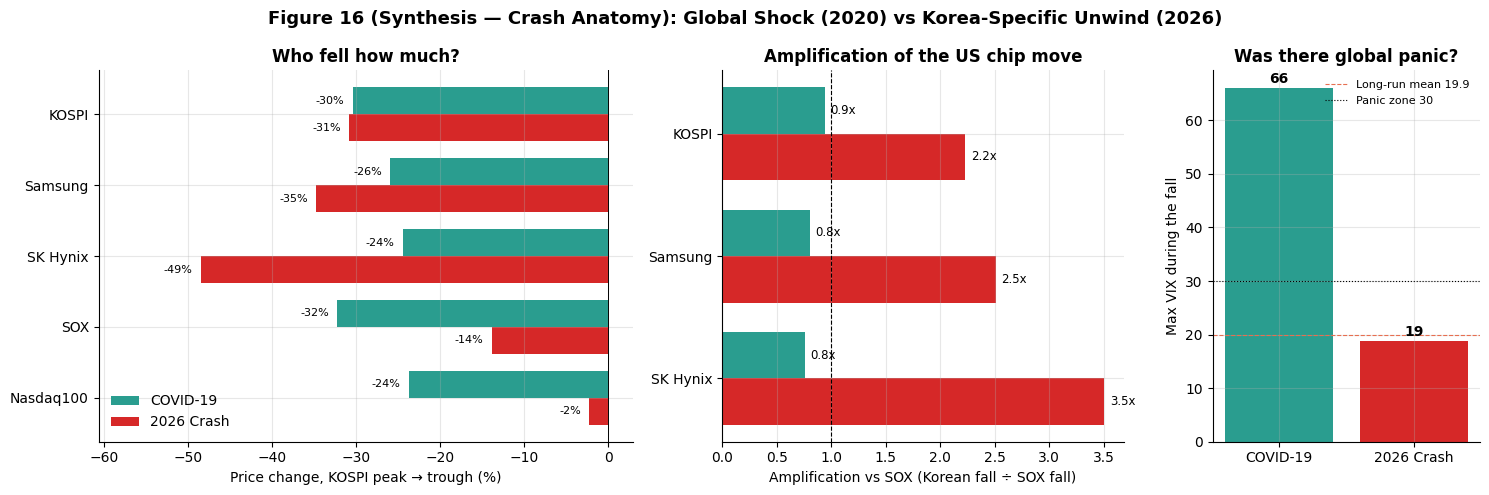

,COVID-19,2026 Crash
KOSPI,-30.4,-30.9
Samsung,-25.9,-34.7
SK Hynix,-24.4,-48.6
SOX,-32.2,-13.8
Nasdaq100,-23.8,-2.2


,COVID-19,2026 Crash
KOSPI,0.94,2.23
Samsung,0.80,2.51
SK Hynix,0.76,3.51


Max VIX: {'COVID-19': 66.0, '2026 Crash': 18.8}


In [19]:
anat_assets = {"KOSPI": "KOSPI", "Samsung": "Samsung", "SK_Hynix": "SK Hynix", "SOX_Index": "SOX", "Nasdaq100_Index": "Nasdaq100"}
anat = {}
for n in ["COVID-19", "2026 Crash"]:
    p, t = crises.loc[n, "Peak"], crises.loc[n, "Trough"]
    anat[n] = {lab: (df_w.loc[t, col] / df_w.loc[p, col] - 1) * 100 for col, lab in anat_assets.items()}
anat = pd.DataFrame(anat)
vix_max = pd.Series({n: df_w.loc[crises.loc[n, "Peak"]:crises.loc[n, "Trough"], "VIX_Index"].max() for n in ["COVID-19", "2026 Crash"]})
amp = anat.loc[["KOSPI", "Samsung", "SK Hynix"]] / anat.loc["SOX"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={"width_ratios": [1.6, 1.2, 0.8]})
ax = axes[0]
y = np.arange(len(anat)); h = 0.38
for j, (n, off) in enumerate([("COVID-19", -h / 2), ("2026 Crash", h / 2)]):
    ax.barh(y + off, anat[n], height=h, color=CRISIS_COLORS[n], label=n)
    for yi, v in zip(y + off, anat[n]):
        ax.text(v - 1, yi, f"{v:.0f}%", va="center", ha="right", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(anat.index); ax.invert_yaxis(); ax.axvline(0, color="black", lw=0.7)
ax.set_xlim(anat.min().min() * 1.25, 3)
ax.set_xlabel("Price change, KOSPI peak → trough (%)"); ax.legend(loc="lower left")
ax.set_title("Who fell how much?")

ax = axes[1]
y2 = np.arange(len(amp))
for n, off in [("COVID-19", -h / 2), ("2026 Crash", h / 2)]:
    ax.barh(y2 + off, amp[n], height=h, color=CRISIS_COLORS[n])
    for yi, v in zip(y2 + off, amp[n]):
        ax.text(v + 0.05, yi, f"{v:.1f}x", va="center", fontsize=8.5)
ax.axvline(1, color="black", ls="--", lw=0.8)
ax.set_yticks(y2); ax.set_yticklabels(amp.index); ax.invert_yaxis()
ax.set_xlabel("Amplification vs SOX (Korean fall ÷ SOX fall)"); ax.set_title("Amplification of the US chip move")

ax = axes[2]
ax.bar(vix_max.index, vix_max, color=[CRISIS_COLORS[n] for n in vix_max.index])
ax.axhline(vix_mean, color=C["vix"], ls="--", lw=0.8, label=f"Long-run mean {vix_mean:.1f}")
ax.axhline(30, color="black", ls=":", lw=0.8, label="Panic zone 30")
for i, v in enumerate(vix_max):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontweight="bold")
ax.set_ylabel("Max VIX during the fall"); ax.legend(loc="upper right", fontsize=8); ax.set_title("Was there global panic?")
fig.suptitle("Figure 16 (Synthesis — Crash Anatomy): Global Shock (2020) vs Korea-Specific Unwind (2026)", fontweight="bold", fontsize=13)
fig.tight_layout()
save(fig, "fig16_synthesis_crash_anatomy")
display(anat.round(1)); display(amp.round(2)); print("Max VIX:", vix_max.round(1).to_dict())

**Figure 17 (Early Warning Matrix)** ตาม Action Plan: De-risk เมื่อ (1) USDKRW Z-score 36 เดือน > 2σ **และ** (2) SOX ปิดต่ำกว่าเส้นค่าเฉลี่ย 12 สัปดาห์

**ป้องกัน Look-ahead Bias:** `usdkrw_monthly` ใช้ `resample("MS").last()` ค่าที่ติดป้ายวันที่ 1 จึงเป็นค่าปลายเดือน ต้องเลื่อนวันที่ "รู้ค่า" ไปเป็นสิ้นเดือนก่อน แล้วค่อย `merge_asof(direction="backward")`
ทดสอบซ้ำกับเกณฑ์ที่ผ่อนลง (Z > 1.5 และ Z > 1) เพื่อดูความไวของผลลัพธ์

,Signal weeks,Fwd 12W return | ON (median %),Fwd 12W return | OFF (median %),Fwd 12W max drawdown | ON (median %),Fwd 12W max drawdown | OFF (median %)
Z threshold,,,,,
2.0,63,1.18,1.86,-4.77,-3.40
1.5,94,1.34,1.86,-5.15,-3.35
1.0,169,2.06,1.80,-4.93,-3.30


,First signal (Z>2),Weeks vs peak,KOSPI at signal vs crisis peak (%)
Crisis,,,
Dot-com,None,NaN,NaN
GFC,2008-09-05,45.0,-30.8
COVID-19,None,NaN,NaN
2026 Crash,2026-04-03,-11.0,-40.6


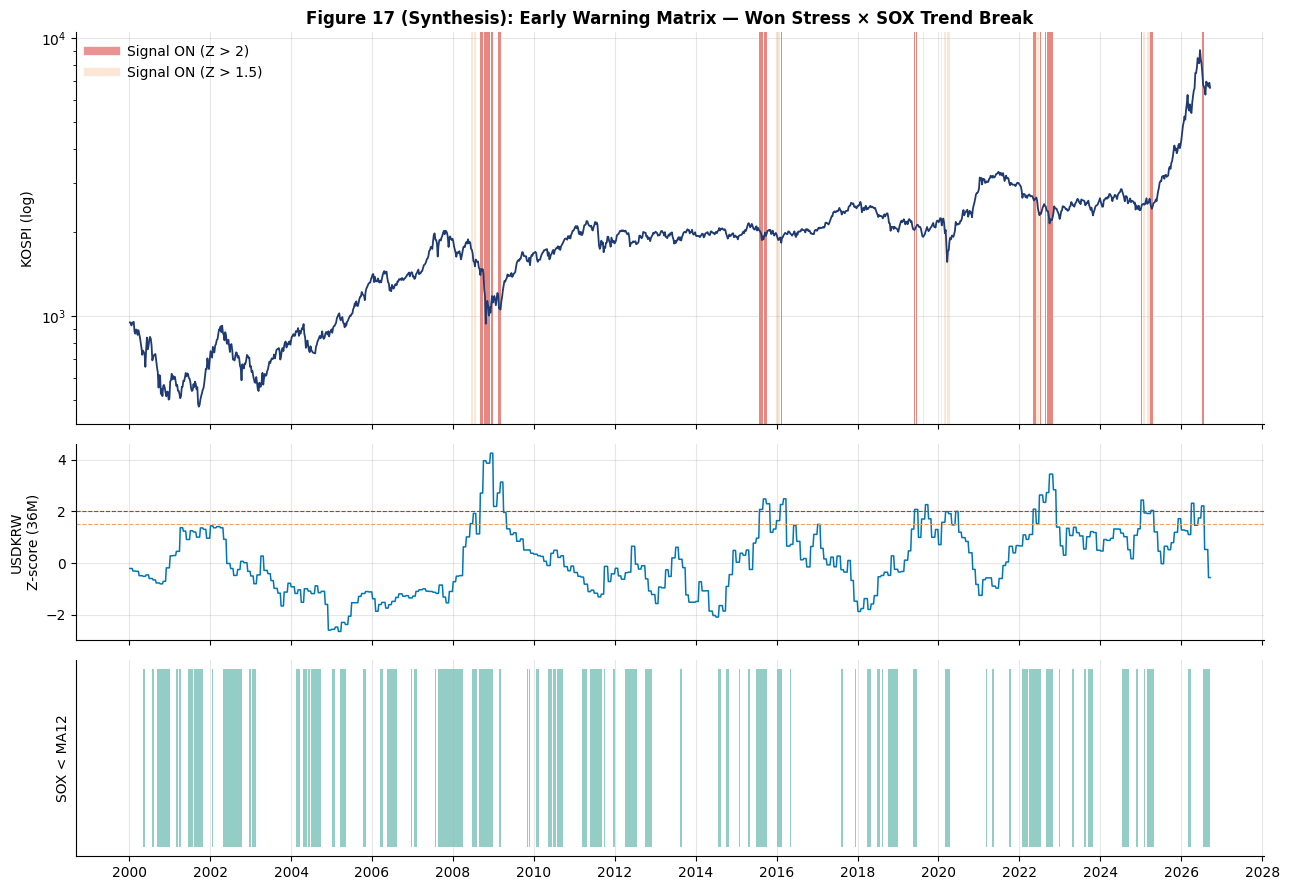

In [20]:
fx_avail = df_m[["USDKRW", "USDKRW_Z36"]].dropna().copy()
fx_avail.index = fx_avail.index + pd.offsets.MonthEnd(0)
fx_avail = fx_avail.reset_index().rename(columns={"Date": "FX_known_date"})

ew = df_w[["KOSPI", "SOX_Index"]].copy()
ew["SOX_MA12"] = ew["SOX_Index"].rolling(12).mean()
ew["SOX_below_MA"] = ew["SOX_Index"] < ew["SOX_MA12"]
ew = pd.merge_asof(ew.reset_index(), fx_avail, left_on="Date", right_on="FX_known_date", direction="backward").set_index("Date")
ew["KOSPI_fwd_12W"] = (ew["KOSPI"].shift(-12) / ew["KOSPI"] - 1) * 100
ew["KOSPI_fwd_maxDD_12W"] = [
    (ew["KOSPI"].iloc[i + 1:i + 13].min() / ew["KOSPI"].iloc[i] - 1) * 100 if i + 12 < len(ew) else np.nan
    for i in range(len(ew))]
ew = ew.loc[MACRO_START:]

tests = []
for th in [2.0, 1.5, 1.0]:
    sig_on = (ew["USDKRW_Z36"] > th) & ew["SOX_below_MA"]
    on, off = ew.loc[sig_on], ew.loc[~sig_on]
    tests.append({"Z threshold": th, "Signal weeks": int(sig_on.sum()),
                  "Fwd 12W return | ON (median %)": on["KOSPI_fwd_12W"].median(),
                  "Fwd 12W return | OFF (median %)": off["KOSPI_fwd_12W"].median(),
                  "Fwd 12W max drawdown | ON (median %)": on["KOSPI_fwd_maxDD_12W"].median(),
                  "Fwd 12W max drawdown | OFF (median %)": off["KOSPI_fwd_maxDD_12W"].median()})
    ew[f"signal_{th}"] = sig_on
test_tbl = pd.DataFrame(tests).set_index("Z threshold")
display(test_tbl.round(2))

timing = []
for n, r in crises.iterrows():
    on = ew.index[ew["signal_2.0"] & (ew.index >= r["Peak"] - pd.Timedelta(weeks=26)) & (ew.index <= r["Trough"] + pd.Timedelta(weeks=4))]
    first = on.min() if len(on) else pd.NaT
    timing.append({"Crisis": n, "First signal (Z>2)": first.date() if pd.notna(first) else None,
                   "Weeks vs peak": (first - r["Peak"]).days // 7 if pd.notna(first) else np.nan,
                   "KOSPI at signal vs crisis peak (%)": (df_w["KOSPI"].asof(first) / r["Peak_KOSPI"] - 1) * 100 if pd.notna(first) else np.nan})
display(pd.DataFrame(timing).set_index("Crisis").round(1))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})
ax = axes[0]
ax.plot(ew.index, ew["KOSPI"], color=C["kospi"], lw=1.3); ax.set_yscale("log")
for th, colr, a in [(1.5, "#f4a261", 0.25), (2.0, "#d62828", 0.5)]:
    on_idx = ew.index[ew[f"signal_{th}"]]
    for d in on_idx:
        ax.axvspan(d - pd.Timedelta(days=6), d, color=colr, alpha=a, lw=0)
ax.plot([], [], color="#d62828", lw=6, alpha=0.5, label="Signal ON (Z > 2)")
ax.plot([], [], color="#f4a261", lw=6, alpha=0.25, label="Signal ON (Z > 1.5)")
ax.set_ylabel("KOSPI (log)"); ax.legend(loc="upper left")
ax.set_title("Figure 17 (Synthesis): Early Warning Matrix — Won Stress × SOX Trend Break")
ax = axes[1]
ax.plot(ew.index, ew["USDKRW_Z36"], color=C["fx"], lw=1.1)
ax.axhline(2, color="#d62828", ls="--", lw=0.8); ax.axhline(1.5, color="#f4a261", ls="--", lw=0.8)
ax.set_ylabel("USDKRW\nZ-score (36M)")
ax = axes[2]
ax.fill_between(ew.index, 0, 1, where=ew["SOX_below_MA"], color=C["sox"], alpha=0.5, step="post", lw=0)
ax.set_yticks([]); ax.set_ylabel("SOX < MA12")
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
save(fig, "fig17_synthesis_early_warning")

## สรุปผลตามสมมติฐาน (จากตัวเลขในโน้ตบุ๊ก)
ตัวเลขด้านล่างอ้างอิงข้อมูลถึงสัปดาห์ 2026-09-11 หากรันใหม่ด้วยข้อมูลที่อัปเดต ต้องทบทวนข้อความให้ตรงกับผลลัพธ์ในตาราง

| สมมติฐาน | หลักฐานจากกราฟ | ผล |
|---|---|---|
| **H1** Stagflation & Rate Trap | Fig 2: ไม่พบเดือนที่ CLI < 100 และ CPI > 3% ใน 12 เดือนก่อน Peak ของวิกฤตใดเลย ปี 2026 CLI อยู่เหนือ 100 และยังเพิ่มขึ้น · Fig 3, 6: Brent ขึ้นไป 110–114 USD ช่วง มี.ค.–เม.ย. 2026 แล้ว CPI YoY ขึ้นเป็น 3.1–3.2% ในเดือน พ.ค.–มิ.ย. ราคาน้ำมันในสกุลวอนส่งผ่านเร็วและแรงกว่า (lag 1–2 เดือน, r ≈ 0.52) · อัตราดอกเบี้ยคงที่ตั้งแต่ พ.ค. 2025 | **สนับสนุนบางส่วน**: มี Cost-push และดอกเบี้ยไม่ขยับ แต่ไม่มีภาพ Stagflation ก่อนวิกฤต |
| **H2** Global Risk-Off & FX Stress | Fig 4, 16: VIX สูงสุดระหว่างการร่วงปี 2026 อยู่ที่ 18.8 ต่ำกว่าค่าเฉลี่ยระยะยาว (COVID-19 = 66) · Fig 5: USDKRW ทะลุ +2σ ในเดือน มิ.ย. 2026 (1,549) ตรงกับเดือน Peak แต่แข็งค่ากลับเป็น 1,368 ใน ส.ค. และในอดีตเดือนที่ทะลุ +2σ ไม่ได้ตามด้วยผลตอบแทนติดลบอย่างเป็นระบบ (median เดือนถัดไป +3.3%, n = 25) | **ไม่สนับสนุน** ในแง่ความตื่นตระหนกระดับโลก ค่าเงินเป็นสัญญาณร่วม ไม่ใช่ตัวจุดชนวนที่เชื่อถือได้ |
| **H3** Concentration Fragility | Fig 11: CR5 (ปรับตัวหาร) เฉลี่ยรายปีเพิ่มจาก 12.5% (2016) เป็น 30.1% (2025) และ 45.7% (2026) สูงสุด 55.5% ปลาย มิ.ย. 2026 (ส่วนหนึ่งกระโดดจากหุ้น IPO เข้ามาในปี 2016 และ 2022) · Fig 12: Top-5 คิดเป็น 69.9% ของมาร์เก็ตแคปที่หายไปในปี 2026 สูงกว่าน้ำหนัก ณ Peak (54%) ขณะที่ช่วง COVID-19 สัดส่วนความเสียหาย (19.8%) ใกล้เคียงน้ำหนัก | **สนับสนุน** |
| **H4** Tech Spillover vs Valuation | Fig 14: KOSPI สัมพันธ์กับ SOX สัปดาห์เดียวกัน r = 0.59 และ lag 1 สัปดาห์ r = 0.17 (ส่วนหนึ่งเป็นผลจากเขตเวลา) หลัง lag 3 สัปดาห์แทบไม่มีความสัมพันธ์ · Fig 13: Rolling correlation 12 สัปดาห์ก่อน Peak สูงกว่าค่าเฉลี่ยในอดีต (SK Hynix–SOX 0.59 เทียบ 0.48) · Fig 16: ช่วงร่วง SOX −13.8% แต่ SK Hynix −48.6% (ขยายผล 3.5 เท่า) · Fig 15: ความไวต่อ US10Y เพิ่มขึ้นในปี 2026 (r = −0.22, n = 37) แต่ยังไม่มีนัยสำคัญที่ระดับ 5% | **สนับสนุนฝั่ง Spillover** · ฝั่ง Valuation Compression ยังสรุปไม่ได้เพราะไม่มีข้อมูล EPS |

**ข้อสรุปรวม:** ข้อมูลชี้ว่าวิกฤต 2026 ใกล้เคียง "การปรับฐานของหุ้นชิปสหรัฐฯ ที่ถูกขยายผลโดยการกระจุกตัวของ KOSPI" มากกว่าวิกฤตมหภาคหรือความตื่นตระหนกระดับโลก KOSPI ขึ้นมากกว่าเท่าตัวในหกเดือนก่อน Peak แล้วร่วง 30.9% ใน 7 สัปดาห์ ซึ่งเร็วที่สุดในสี่วิกฤตที่เปรียบเทียบ (Fig 7)

**Early Warning Matrix (Fig 17):** กฎ Z > 2σ ร่วมกับ SOX < MA12 ให้สัญญาณในปี 2026 สองครั้ง คือ 2026-04-03 (ก่อน Peak 11 สัปดาห์ แต่ KOSPI ยังขึ้นต่ออีกราว 68%) และ 2026-07-17 (หลัง Peak 4 สัปดาห์) ค่ามัธยฐานของ Max Drawdown 12 สัปดาห์ข้างหน้าเมื่อสัญญาณติดคือ −4.8% เทียบกับ −3.4% เมื่อไม่ติด กฎนี้จึงช่วยได้จำกัด ข้อจำกัดหลักคือ USDKRW เป็นข้อมูลรายเดือน สัญญาณจึงช้าไปหนึ่งเดือน แนวทางปรับปรุงที่ทดสอบต่อได้ ได้แก่ ใช้ USDKRW รายวัน และเพิ่มเงื่อนไข CR5 หรือระยะห่างของ KOSPI จากเส้นค่าเฉลี่ย

**ข้อจำกัดของข้อมูล:** (1) `PolicyRate_Korea` เป็น Discount Rate ไม่ใช่ Base Rate (2) CR5 ใช้จำนวนหุ้น ณ วันดึงข้อมูลย้อนหลังทั้งช่วง และตัวหารที่ปรับแล้วยังเป็นค่าประมาณ (3) GDP รายเดือนได้จากการ interpolate รายไตรมาส ซึ่งใช้ค่าไตรมาสถัดไป ห้ามใช้เป็นตัวแปรพยากรณ์ (4) ความสัมพันธ์ที่พบไม่ได้พิสูจน์ความเป็นเหตุเป็นผล